# 0. Directories and Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/ml_term_project/nyc

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ml_term_project/nyc


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Latex
import os

# 1. Initial Cleaning and EDA

In this section we will first do quick cleaning processes and then some EDA that will help us give a more honed direction later on for extended analysis.

In [ ]:
# Load the nyc rolling sales data set

nyc_df = pd.read_csv('nyc-rolling-sales.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 3)

In [ ]:
# Check first few samples of data set to ensure proper loading

nyc_df.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,,10009,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,,10009,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,,10009,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,,10009,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,,10009,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [ ]:
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null


There are 84548 samples and 21 raw features with one dependent variable being the 'SALE PRICE' at first glance. We can see that we something called 'Unnamed: 0' which is just an indexing column, so we can ignore that as we will drop that. The only numerical variables are SALE PRICE, SALE DATE, YEAR BUILT, GROSS SQUARE FEET, LAND SQAURE FEET, TOTAL UNITS, COMMERICAL UNITS, and RESIDENTIAL UNITS. The rest of them are categorical, specifically nominal and none are ordinal. We have some other features like APARTMENT NUMBER and ADDRESS which can be classified as identifiers as well. So we actually only have 18 features that we can use for prediction given this information. The Dtypes that are currently assigned do not reflect the true nature of the features, so we must change them for clarity purposes as well.

In [ ]:
# Indexing column, no use of it
nyc_df=nyc_df.drop(columns=['Unnamed: 0'])

# Remove duplicate values
nyc_df =  nyc_df.drop_duplicates().reset_index(drop=True)

Here we remove the unnamed indexing column and also drop all duplicate samples so that our data doesn't get too skewed. We keep ADDRESS in case we need to look at specific samples and APARTMENT NUMBER to verify it would indeed be of no benefit.

In [ ]:
# Extract year and month then drop SALE DATE

nyc_df['SALE DATE'] = pd.to_datetime(nyc_df['SALE DATE'])
nyc_df['SALE YEAR'] = nyc_df['SALE DATE'].dt.year
nyc_df['SALE MONTH'] = nyc_df['SALE DATE'].dt.month

nyc_df=nyc_df.drop(columns=['SALE DATE'])

# Convert columns to numeric format
num_col = ['APARTMENT NUMBER', 'ZIP CODE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'SALE PRICE']
nyc_df[num_col] = nyc_df[num_col].apply(pd.to_numeric, errors='coerce')

# Convert to categorical format
col_list = ['BOROUGH' , 'NEIGHBORHOOD', 'ADDRESS', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'BUILDING CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE']

nyc_df[col_list] = nyc_df[col_list].astype('category')

# For clarity purposes
nyc_df['BOROUGH'] = nyc_df['BOROUGH'].cat.rename_categories({
    1: 'Manhattan',
    2: 'Brooklyn',
    3: 'Queens',
    4: 'Bronx',
    5: 'Staten Island'
})

nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83783 entries, 0 to 83782
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         83783 non-null  category
 1   NEIGHBORHOOD                    83783 non-null  category
 2   BUILDING CLASS CATEGORY         83783 non-null  category
 3   TAX CLASS AT PRESENT            83783 non-null  category
 4   BLOCK                           83783 non-null  int64   
 5   LOT                             83783 non-null  int64   
 6   EASE-MENT                       83783 non-null  object  
 7   BUILDING CLASS AT PRESENT       83783 non-null  category
 8   ADDRESS                         83783 non-null  category
 9   APARTMENT NUMBER                3802 non-null   float64 
 10  ZIP CODE                        83783 non-null  int64   
 11  RESIDENTIAL UNITS               83783 non-null  int64   
 12  COMMERCIAL UNITS  

We first split the SALE DATE column into SALE YEAR and SALE MONTH so that we can potentially make use of them. We then convert the numerical features to numeric format. Although ZIP CODE and APARTMENT NUMBER aren't exactly numerical features, we convert them for ease of use within the dataframe and not to perform numerical calculations. And then we convert the corresponding categorical features to category within the dataframe. Some are left as object for a reason we will see later.

In [ ]:
# Print number of unique values per column

unique_counts = nyc_df.nunique()

print("Number of unique values in each column:\n")
for col, count in unique_counts.items():
    print(f"{col}: {count}")

Number of unique values in each column:

BOROUGH: 5
NEIGHBORHOOD: 254
BUILDING CLASS CATEGORY: 47
TAX CLASS AT PRESENT: 11
BLOCK: 11566
LOT: 2627
EASE-MENT: 1
BUILDING CLASS AT PRESENT: 167
ADDRESS: 67563
APARTMENT NUMBER: 788
ZIP CODE: 186
RESIDENTIAL UNITS: 176
COMMERCIAL UNITS: 55
TOTAL UNITS: 192
LAND SQUARE FEET: 6061
GROSS SQUARE FEET: 5690
YEAR BUILT: 158
TAX CLASS AT TIME OF SALE: 4
BUILDING CLASS AT TIME OF SALE: 166
SALE PRICE: 10007
SALE YEAR: 2
SALE MONTH: 12


After printing the number of unique values per column, we can see here that EASE-MENT only has one unique value, which won't help in predicting the sale price, so we can drop it. SALE YEAR is either 2016 or 2017, since that is the timeframe of sales this dataset focuses on. Later on, we can convert this to age at time of sale to give a possibly better feature while reducing dimensionality after investigating for anomalies in all features. We can also check if there are differences in TAX CLASS AT PRESENT and AT TIME OF SALE, same for Building class so that we can maybe remove duplicate columns.

In [ ]:
# Drop EASE-MENT because only one unique value

nyc_df=nyc_df.drop(columns=['EASE-MENT'])

In [ ]:
# Check the metrics for the numerical features

nyc_df.describe().apply(lambda x: x.apply('{0:.2f}'.format)).transpose()

,count,mean,std,min,25%,50%,75%,max
BLOCK,83783.00,4242.90,3568.79,1.00,1326.00,3319.00,6295.00,16322.00
LOT,83783.00,376.14,658.02,1.00,22.00,50.00,1001.00,9106.00
APARTMENT NUMBER,3802.00,951.73,4747.91,0.00,4.00,67.00,529.00,87001.00
ZIP CODE,83783.00,10733.24,1289.76,0.00,10305.00,11209.00,11357.00,11694.00
RESIDENTIAL UNITS,83783.00,2.00,16.57,0.00,0.00,1.00,2.00,1844.00
COMMERCIAL UNITS,83783.00,0.18,8.58,0.00,0.00,0.00,0.00,2261.00
TOTAL UNITS,83783.00,2.21,18.78,0.00,1.00,1.00,2.00,2261.00
LAND SQUARE FEET,57729.00,3854.48,41547.37,0.00,1643.00,2314.00,3500.00,4252327.00
GROSS SQUARE FEET,56398.00,3894.42,34837.26,0.00,1040.00,1680.00,2552.00,3750565.00
YEAR BUILT,83783.00,1789.81,536.57,0.00,1920.00,1940.00,1965.00,2017.00


Here we can see that SALE PRICE has a minimum of $0, which we can classify as an anomaly.

A 0 dollar sale indicates that there was a transfer of ownership without a cash consideration, such as a transfer of ownership from parents to children. Since these are not valid sales, we can drop the samples with a sale price of $0.

There are also values of 0 for GROSS SQUARE FEET(GSF), LAND SQUARE FEET(LSF), YEAR BUILT, ZIP CODE, RESIDENTIAL, COMMERCIAL, and TOTAL UNITS. We will investigate these further after verifying the amount of NaN values per column.

In [ ]:
# Replace missing values with NaN
nyc_df = nyc_df.replace(['', ' ', '  ', '-'], np.nan)

# Print percentage of $0 sales
freq = ((nyc_df['SALE PRICE'] == 0).sum())/(len(nyc_df))*100
print(f'Percent of $0 sales: {freq}%\n')

# Print percentage of NaN values
print('Sum of NaNs by column and percentage: \n')
print(nyc_df.isna().sum()[nyc_df.isna().any()])
print("----------------------------------")
print(nyc_df.isna().mean() * 100)

Percent of $0 sales: 11.949918241170643%

Sum of NaNs by column and percentage: 

TAX CLASS AT PRESENT           738
BUILDING CLASS AT PRESENT      738
APARTMENT NUMBER             79981
LAND SQUARE FEET             26054
GROSS SQUARE FEET            27385
SALE PRICE                   14176
dtype: int64
----------------------------------
BOROUGH                            0.000
NEIGHBORHOOD                       0.000
BUILDING CLASS CATEGORY            0.000
TAX CLASS AT PRESENT               0.881
BLOCK                              0.000
LOT                                0.000
BUILDING CLASS AT PRESENT          0.881
ADDRESS                            0.000
APARTMENT NUMBER                  95.462
ZIP CODE                           0.000
RESIDENTIAL UNITS                  0.000
COMMERCIAL UNITS                   0.000
TOTAL UNITS                        0.000
LAND SQUARE FEET                  31.097
GROSS SQUARE FEET                 32.686
YEAR BUILT                         0.000
TAX 

/tmp/ipython-input-1384420285.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  nyc_df = nyc_df.replace(['', ' ', '  ', '-'], np.nan)


From this we can see that about 11% of samples have $0 sales, thus we will remove these since they aren't part of the goal for this project and will not be a good reflection of the actual sale price distribution for the model's predictions. We also replaced some common empty value placeholders for all columns with NaN for easier identification. After doing this, we can see that APARTMENT NUMBER has 95% missing values, so we will also drop this feature. TAX CLASS AT PRESENT and BUILDING CLASS AT PRESENT have the same rate of missing values, it is possible that they coincide, we will check this. LSF, GSF, and SALE PRICE account for most of the missing values for the strong features. The anomalies we discovered before will also confuse the model since it logically shouldn't be possible to have a LSF or GSF, etc. of value 0. Like the sale price, these will skew the data towards a false direction for the model while introducing noise. In the next sections of this notebook, we will conduct a detailed analysis on this to see if there is possibility of imputation.

In [ ]:
# Dropping $0 sales

nyc_df = nyc_df[nyc_df['SALE PRICE'] != 0].reset_index(drop=True)

# High amount of NA values and also specific apartment number won't be a strong feature, so we drop
nyc_df=nyc_df.drop(columns=['APARTMENT NUMBER'])

# 2. Investigation of Anomalies

This section is mainly for trying to find all anomalies among features and then figuring out ways to deal with them via imputing or possibly dropping the samples.

Let us first revisit TAX CLASS AT PRESENT and BUILDING CLASS AT PRESENT since they had the same percentage of missing values at about 0.9%.

In [ ]:
# Check if the two columns have missing values in the same samples

missing_col1 = nyc_df[nyc_df['TAX CLASS AT PRESENT'].isna()].index
missing_col2 = nyc_df[nyc_df['BUILDING CLASS AT PRESENT'].isna()].index

print(f"Are these the same samples? {missing_col1.tolist() == missing_col2.tolist()}")

Are these the same samples? True


In [ ]:
# Taking a look to see other correlations

missing_df = nyc_df[nyc_df['TAX CLASS AT PRESENT'].isna()]
missing_df.head(20)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,BUILDING CLASS AT PRESENT,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE YEAR,SALE MONTH
74,Manhattan,ALPHABET CITY,11A CONDO-RENTALS,NaN,394,1602,NaN,183-189 AVENUE B,0,0,0,0,NaN,NaN,0,2,RR,8.059e+06,2017,8
198,Manhattan,ALPHABET CITY,42 CONDO CULTURAL/MEDICAL/EDUCATIONAL/ETC,NaN,394,1601,NaN,183-189 AVENUE B,0,0,0,0,NaN,NaN,0,4,RA,NaN,2017,8
570,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1306,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,7.166e+06,2017,8
571,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1309,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,4.937e+06,2017,8
572,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1311,NaN,520 WEST 28TH STREET,0,0,0,0,NaN,NaN,0,2,R4,6.033e+06,2017,6
573,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1316,NaN,520 WEST 28TH STREET,0,0,0,0,NaN,NaN,0,2,R4,6.199e+06,2017,6
574,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1317,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,1.450e+07,2017,8
575,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1319,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,4.988e+06,2017,7
576,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1320,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,5.191e+06,2017,7
577,Manhattan,CHELSEA,13 CONDOS - ELEVATOR APARTMENTS,NaN,699,1321,NaN,510 WEST 28TH STREET,10001,0,0,0,NaN,NaN,0,2,R4,6.398e+06,2017,7


In [ ]:
# Checking if it may also be resulted from anomalies in other columns

value = 0
column = 'TOTAL UNITS'
all_equal = (missing_df[column] == value).all()
print(f"All values in '{column}' equal '{value}': {'Yes' if all_equal else 'No'}")

print(missing_df['LAND SQUARE FEET'].unique())
print(missing_df['GROSS SQUARE FEET'].unique())

All values in 'TOTAL UNITS' equal '0': Yes
[nan  0.]
[nan  0.]


We have determined that the missing values in these two columns are correlated with each other, and that they are further correlated with there not being information on GSF, LSF, and Total Units. Thus it would be very hard to impute these values without this important information, so we will drop the samples corresponding to this since they make up less than 1% of the dataset.

In [ ]:
# Dropping NaN values in Tax class at present

nyc_df = nyc_df.dropna(subset=['TAX CLASS AT PRESENT'])
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73113 entries, 0 to 73770
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         73113 non-null  category
 1   NEIGHBORHOOD                    73113 non-null  category
 2   BUILDING CLASS CATEGORY         73113 non-null  category
 3   TAX CLASS AT PRESENT            73113 non-null  category
 4   BLOCK                           73113 non-null  int64   
 5   LOT                             73113 non-null  int64   
 6   BUILDING CLASS AT PRESENT       73113 non-null  category
 7   ADDRESS                         73113 non-null  category
 8   ZIP CODE                        73113 non-null  int64   
 9   RESIDENTIAL UNITS               73113 non-null  int64   
 10  COMMERCIAL UNITS                73113 non-null  int64   
 11  TOTAL UNITS                     73113 non-null  int64   
 12  LAND SQUARE FEET       

Let us also check if we see consistent values across some categorical columns

In [ ]:
# Checking if they have the same unique values or not

print(nyc_df['TAX CLASS AT PRESENT'].unique())
print(nyc_df['TAX CLASS AT TIME OF SALE'].unique())

# Re-Mapping the values
nyc_df['TAX CLASS AT PRESENT'] = nyc_df['TAX CLASS AT PRESENT'].astype(str).str[0].astype(int)
nyc_df['TAX CLASS AT PRESENT'] = nyc_df['TAX CLASS AT PRESENT'].astype('category')


['2A', '2', '2B', '2C', '4', '1', '1C', '3', '1A', '1B']
Categories (10, object): ['1', '1A', '1B', '1C', ..., '2B', '2C', '3', '4']
[2, 4, 1, 3]
Categories (4, int64): [1, 2, 3, 4]


Checking the NYC government glossary, they don't really subdivide the tax classes, so they may not hold much important meaning and could distort the model due to the mismatch between present and time of sale classes. So I got rid of the extras to further reduce dimensionality when encoding is done. I did not do this for building class because of the large amount of unique values.


Now lets check for GSF, LSF, Sale price, and Total Units for anomalies as well and see what to do with. We will define anomalies as sale prices less than or equal to 10 dollars, GSF, LSF, ZIP CODE, and Year built = 0, also where total units < residential + commercial units

In [ ]:
# Abnormal is defined as when some features = 0 when they shouldnt or if houses are sold for $1

# Inconsistent is defined as when residential + commercial > total
numeric_cols = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS']

for col in numeric_cols:
    if col in ['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS']:
        continue

    abnormal = ((nyc_df[col] <= 10).sum() / len(nyc_df)) * 100 if col == 'SALE PRICE' else ((nyc_df[col] == 0).sum() / len(nyc_df)) * 100
    nan_val = (nyc_df[col].isna().sum() / len(nyc_df)) * 100
    total = abnormal + nan_val

    print(f"{col}: Abnormal={abnormal:.2f}% | NaN={nan_val:.2f}% | Total={total:.2f}%")

print(f"\nRESIDENTIAL/COMMERCIAL/TOTAL UNITS:")
nan_pct = ((nyc_df[['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS']].isna().any(axis=1)).sum() / len(nyc_df)) * 100

# Only check inconsistency where all three have non-null values
non_na= nyc_df[['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS']].notna().all(axis=1)
inconsistent = ((non_na) & (nyc_df['TOTAL UNITS'] < (nyc_df['RESIDENTIAL UNITS'] + nyc_df['COMMERCIAL UNITS']))).sum() / len(nyc_df) * 100

print(f"  NaN={nan_pct:.2f}% | Inconsistent={inconsistent:.2f}% | Total={nan_pct + inconsistent:.2f}%")

SALE PRICE: Abnormal=1.20% | NaN=19.30% | Total=20.50%
LAND SQUARE FEET: Abnormal=10.82% | NaN=35.11% | Total=45.93%
GROSS SQUARE FEET: Abnormal=11.49% | NaN=36.93% | Total=48.42%
YEAR BUILT: Abnormal=7.09% | NaN=0.00% | Total=7.09%
ZIP CODE: Abnormal=0.66% | NaN=0.00% | Total=0.66%

RESIDENTIAL/COMMERCIAL/TOTAL UNITS:
  NaN=0.00% | Inconsistent=0.04% | Total=0.04%


In [ ]:
correlation_matrix = nyc_df.corr(numeric_only = True)
print(correlation_matrix)

                       BLOCK    LOT   ZIP CODE  RESIDENTIAL UNITS  \
BLOCK              1.000e+00 -0.244  2.974e-01         -1.300e-02   
LOT               -2.436e-01  1.000 -1.191e-01         -3.042e-02   
ZIP CODE           2.974e-01 -0.119  1.000e+00         -8.976e-04   
RESIDENTIAL UNITS -1.300e-02 -0.030 -8.976e-04          1.000e+00   
COMMERCIAL UNITS  -1.883e-03 -0.010 -6.250e-04          1.582e-02   
TOTAL UNITS       -1.283e-02 -0.029 -1.060e-03          8.803e-01   
LAND SQUARE FEET  -2.397e-04 -0.020 -5.485e-02          4.216e-01   
GROSS SQUARE FEET -4.267e-02 -0.016 -4.447e-02          7.620e-01   
YEAR BUILT         6.871e-02 -0.268  2.544e-01          1.956e-02   
SALE PRICE        -6.152e-02  0.009 -3.500e-02          1.361e-01   
SALE YEAR         -8.713e-03  0.010 -7.657e-03         -8.851e-03   
SALE MONTH         8.031e-03 -0.006  8.646e-03          1.172e-02   

                   COMMERCIAL UNITS  TOTAL UNITS  LAND SQUARE FEET  \
BLOCK                    -1.883e

After taking a look we can see that most anomalies lie with GSF, LSF, and Sale price. Typically GSF and LSF would be assumed to be the most correlated with Sale price out of these features and we can see this via a correlation matrix. So if around 50% of GSF is missing values, this would cause a problem for the prediction model, and we will need to remedy this. For now, we can remove the odd values in ZIP CODE and TOTAL UNITs since they account for a very low percentage of the data set as well.

In [ ]:
# Dropping zip codes and inconsistent unit size

nyc_df = nyc_df[nyc_df['ZIP CODE'] != 0].reset_index(drop=True)
nyc_df = nyc_df[nyc_df['TOTAL UNITS'] >= nyc_df['RESIDENTIAL UNITS'] + nyc_df['COMMERCIAL UNITS']].reset_index(drop=True)

nyc_df.shape

(72603, 20)

Now lets take a look at the Year built feature

In [ ]:
# Extracting samples year built = 0

extracted_df = nyc_df.loc[nyc_df['YEAR BUILT']== 0]

print(extracted_df.shape)
unique_counts = extracted_df.nunique()

print("Number of unique values in each column:\n")
for col, count in unique_counts.items():
    print(f"{col}: {count}")

(4751, 20)
Number of unique values in each column:

BOROUGH: 5
NEIGHBORHOOD: 217
BUILDING CLASS CATEGORY: 27
TAX CLASS AT PRESENT: 4
BLOCK: 1413
LOT: 1222
BUILDING CLASS AT PRESENT: 39
ADDRESS: 2699
ZIP CODE: 169
RESIDENTIAL UNITS: 8
COMMERCIAL UNITS: 2
TOTAL UNITS: 8
LAND SQUARE FEET: 579
GROSS SQUARE FEET: 14
YEAR BUILT: 1
TAX CLASS AT TIME OF SALE: 4
BUILDING CLASS AT TIME OF SALE: 39
SALE PRICE: 1313
SALE YEAR: 2
SALE MONTH: 12


We can see that the samples with year built = 0, there doesn't appear to be a common pattern among the other features to indicate why it was never recorded. Due to these samples representing 7% of the dataset, we should drop them since it would be very hard to impute the age, requiring complex algorithms.

In [ ]:
# Dropping said samples

nyc_df = nyc_df[nyc_df['YEAR BUILT'] != 0].reset_index(drop=True)
nyc_df.shape

(67852, 20)

In [ ]:
nyc_df.skew(numeric_only=True)

,0
BLOCK,1.037
LOT,3.413
ZIP CODE,-0.371
RESIDENTIAL UNITS,62.052
COMMERCIAL UNITS,205.395
TOTAL UNITS,64.429
LAND SQUARE FEET,84.598
GROSS SQUARE FEET,61.215
YEAR BUILT,0.151
SALE PRICE,116.222


For similar reasons above, we will be dropping the samples that have anomalies among LSF, GSF, and Sale price since they constitute a large number of the data set, and performing imputations would generally take a long time if we were to do it multivariately. Using mean, median, etc. imputation would most likely distort the dataset because the dataset is already very skewed due to the disparity in properties, ranging from $1 to about 22 billion dollars. I will classify this as Missing At Random, could also be classified as Missing Completely At Random. Given their limitations, these imputation methods may not give great performance. Also, the 1 dollar prices most likely correspond to gifting of properties or irregular sales, which don't represent true sales.

In [ ]:
nyc_df = nyc_df[nyc_df['LAND SQUARE FEET'] != 0].reset_index(drop=True)
nyc_df = nyc_df[nyc_df['GROSS SQUARE FEET'] != 0].reset_index(drop=True)
nyc_df = nyc_df[nyc_df['SALE PRICE'] > 10].reset_index(drop=True)
nyc_df = nyc_df.dropna(subset=['GROSS SQUARE FEET', 'LAND SQUARE FEET', 'SALE PRICE']).reset_index(drop=True)
nyc_df.shape
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BLOCK                           28516 non-null  int64   
 5   LOT                             28516 non-null  int64   
 6   BUILDING CLASS AT PRESENT       28516 non-null  category
 7   ADDRESS                         28516 non-null  category
 8   ZIP CODE                        28516 non-null  int64   
 9   RESIDENTIAL UNITS               28516 non-null  int64   
 10  COMMERCIAL UNITS                28516 non-null  int64   
 11  TOTAL UNITS                     28516 non-null  int64   
 12  LAND SQUARE FEET  

# 3. Distribution & Correlation Analysis of Numerical Features

We will first look at the numeric features

In [ ]:
# Checking skew

nyc_df.skew(numeric_only=True)

,0
BLOCK,0.722
LOT,16.339
ZIP CODE,-0.688
RESIDENTIAL UNITS,46.034
COMMERCIAL UNITS,150.196
TOTAL UNITS,53.151
LAND SQUARE FEET,83.430
GROSS SQUARE FEET,61.837
YEAR BUILT,0.798
SALE PRICE,87.755


As we can see here, some of the homes are skewing the data to the right highly, lets plot their distributions without the outliers to see how they are. We skip SALE YEAR and SALE MONTH because they have correct values from our analysis of the definition table from before. Lets visualize this further.

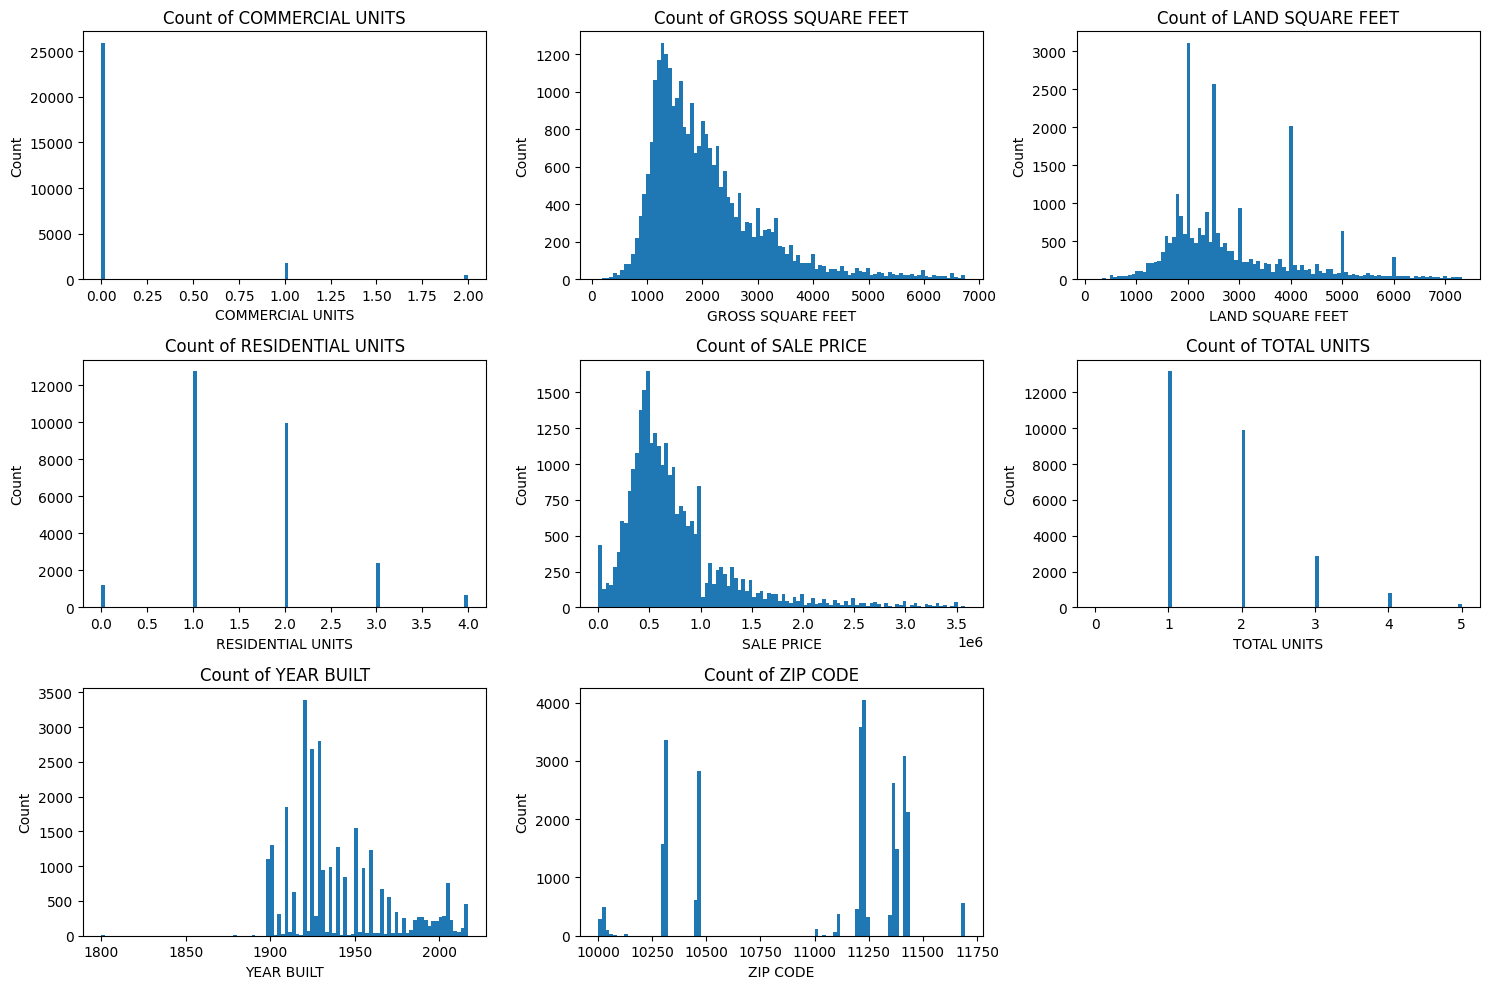

In [ ]:
# Plotting the histogram distributions with thresholds to reduce extreme outliers

columns_to_exclude = ['SALE YEAR', 'SALE MONTH', 'BLOCK', 'LOT', 'APARTMENT NUMBER']
numeric_cols = nyc_df.select_dtypes(include=['number']).columns.difference(columns_to_exclude)

fig, axes = plt.subplots(nrows=3, ncols = 3, figsize=(15, 10))
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
  if col in ['YEAR BUILT', 'ZIP CODE']:
    axes[i].hist(nyc_df[col], bins=100)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)

  elif col in ['COMMERCIAL UNITS']:
    threshold_upper = nyc_df[col].quantile(.99)

    nyc_df_plot = nyc_df[(nyc_df[col] < threshold_upper)]
    axes[i].hist(nyc_df_plot[col], bins=100)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)


  else:
    threshold_upper = nyc_df[col].quantile(.95)
    nyc_df_plot = nyc_df[(nyc_df[col] < threshold_upper)]
    axes[i].hist(nyc_df_plot[col], bins=100)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Histograms show that the sale price, GSF, and LSF follows a generally gaussian distribution, and at around $100000 we can see that it starts to have generally a lot of outliers. So we can classify those as the outliers on the high end of the data set. The outliers for GSF and LSF are most likely the same houses as well. These outliers will significantly affect the model due to linear regression's reliance on distance metrics, especially for MSE. So it will be beneficial to come up with a strategy to combat this for later.

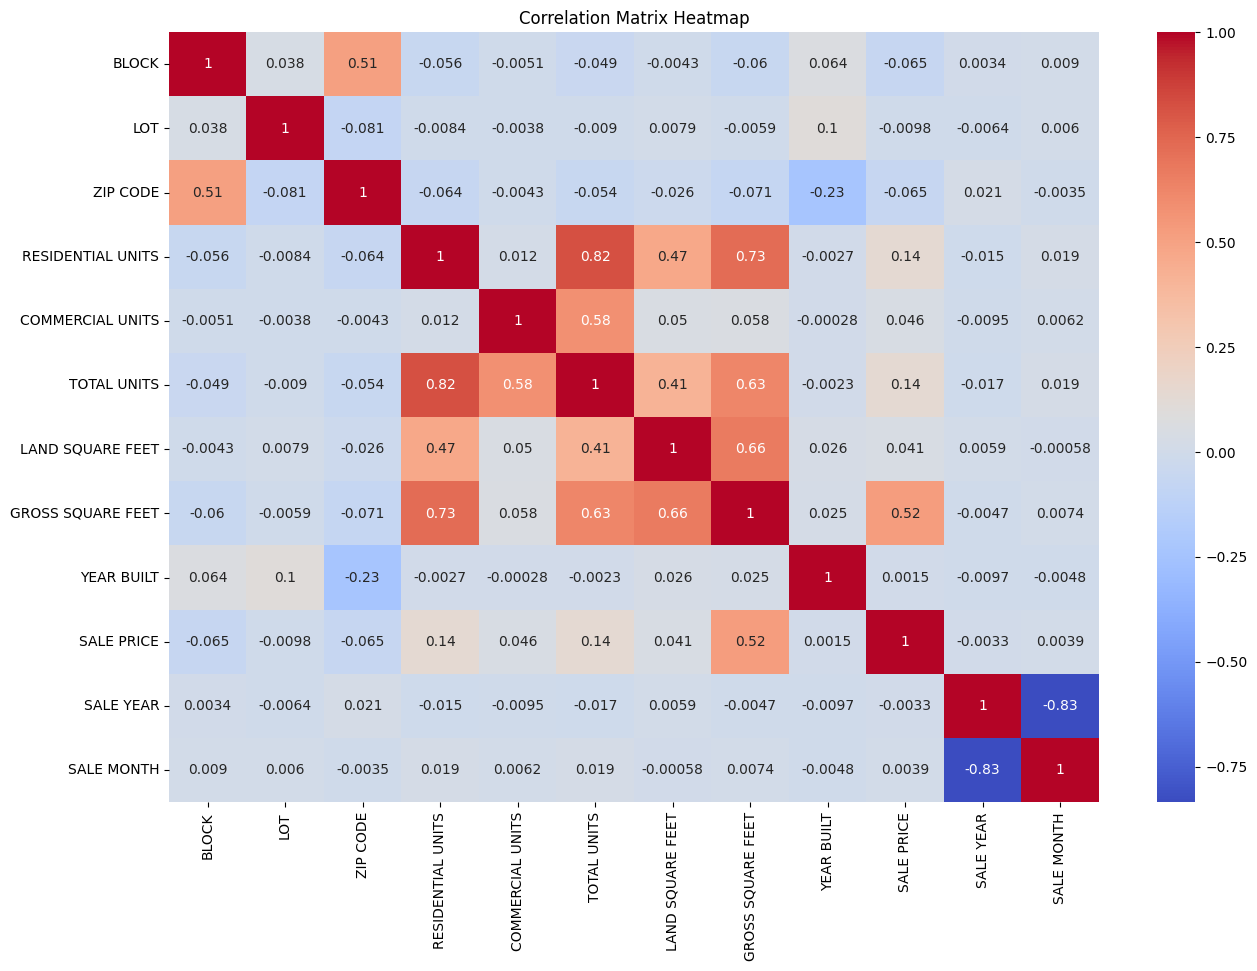

In [ ]:
# Create correlation matrix for numerical features

corr_matrix = nyc_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

As we can see here zip codes don't seem to be that strongly correlated with the sale price. The ones that are most strongly correlated are GSF, Total Units, and Residential Units. Since there are already a low number of commercial units in each property, this is most likely why it is not that correlated with sale price. And these correlations with Units come from the fact that they are highly correlated with the GSF as well. Sale Month and Year aren't very correlated with the sale price as well which is kind of suprising but most likely because they are separated. Year Built isn't that correlated with Sale Price as well, so it brings some justification to dropping the 0 valued Year Built. We will investigate individual pairplots for further analysis of correlation between variables.

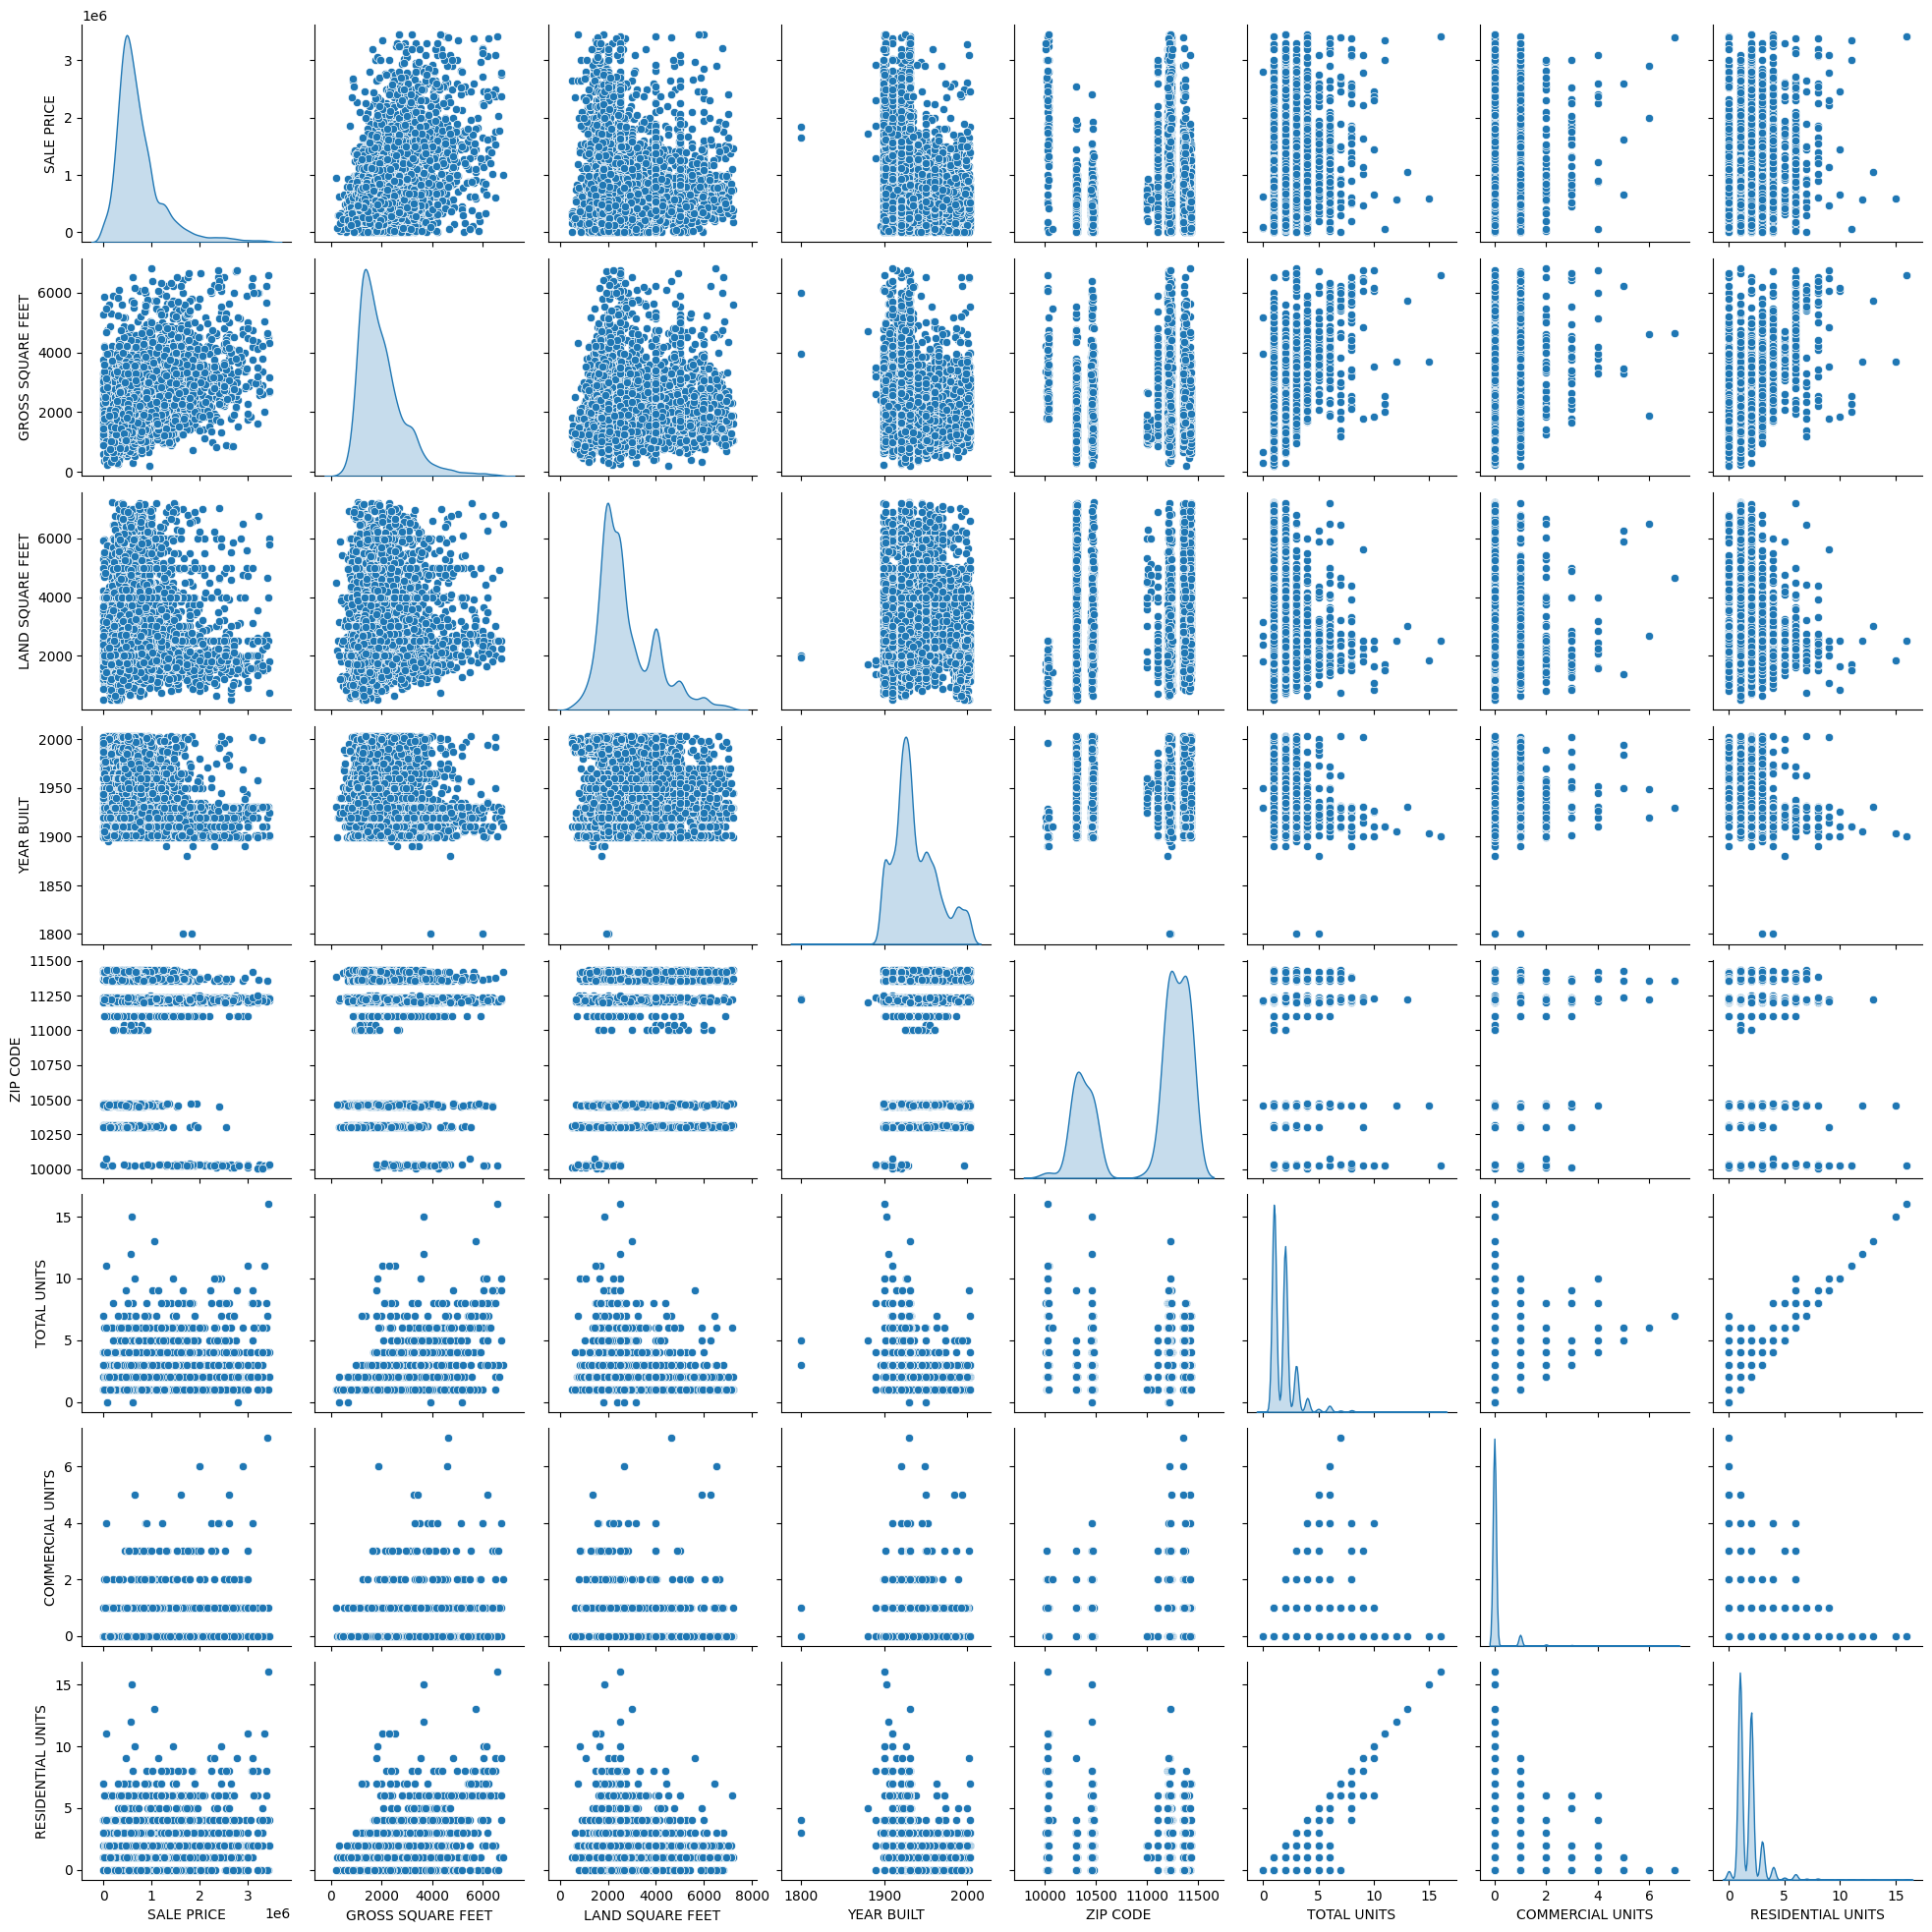

In [ ]:
# Random sample to optimize plotting for Sale price, LSF, GSF and also optimized for outliers

sample_df = nyc_df.sample(n=10000, random_state=42)

cols_plot = ['SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET', 'YEAR BUILT',
             'ZIP CODE', 'TOTAL UNITS', 'COMMERCIAL UNITS', 'RESIDENTIAL UNITS']
nyc_df_plot = sample_df[cols_plot].copy()

mask = pd.Series([True] * len(nyc_df_plot), index=nyc_df_plot.index)

for col in cols_plot:
    if col in ['SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET', 'ZIP CODE', 'YEAR BUILT']:
        threshold_upper = nyc_df_plot[col].quantile(.95)
        mask &= (nyc_df_plot[col] < threshold_upper) & (nyc_df_plot[col] > 1)

    elif col in ['TOTAL UNITS', 'COMMERCIAL UNITS', 'RESIDENTIAL UNITS']:
        threshold_upper = nyc_df_plot[col].quantile(1)
        mask &= (nyc_df_plot[col] < threshold_upper)

nyc_df_plot = nyc_df_plot[mask]

sns.pairplot(nyc_df_plot, diag_kind='kde')
plt.show()

Taking a look at these sampled pairplots, We can see the distributions more clearly of the features here, they appear to be relatively normally distributed, with ZIP CODE having something more irregular, but this is due to its categorical nature, so we ignore that. Sale Price vs GSF appears to be kind of trending towards linear, but not very strong which we saw with the correlation being around .5 ish. And otherwise not very correlated with the rest. This is most likely due to the pricing in NYC not being due to LSF as much and more on area and city value, so things like neighborhood would be very imporant there. There is a linear correlation between total units and residential units which is probably due to how most properties are residential. And generally not many linear correlations between features and the sale price label. We can possibly do some feature learning with total units due to this high correlation as well and completely remove it later on.

# 4. Distribution & Correlation Analysis of Categorical Features

So now we have removed all NaN values and anomalies within the data. Let us go over the categorical features now.

In [ ]:
# Printing Unique Values for each categorical data type

cat_cols = nyc_df.select_dtypes(include=['category']).columns.tolist()
print(cat_cols)
for col in cat_cols:
    unique_vals = nyc_df[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique):")
    print(f"  {unique_vals}")

['BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE']

BOROUGH (5 unique):
  ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
Categories (5, object): ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

NEIGHBORHOOD (249 unique):
  ['ALPHABET CITY', 'CHELSEA', 'CHINATOWN', 'CIVIC CENTER', 'CLINTON', ..., 'TRAVIS', 'WEST NEW BRIGHTON', 'WESTERLEIGH', 'WILLOWBROOK', 'WOODROW']
Length: 249
Categories (254, object): ['AIRPORT LA GUARDIA', 'ALPHABET CITY', 'ANNADALE', 'ARDEN HEIGHTS', ...,
                           'WOODLAWN', 'WOODROW', 'WOODSIDE', 'WYCKOFF HEIGHTS']

BUILDING CLASS CATEGORY (30 unique):
  ['07 RENTALS - WALKUP APARTMENTS             ', '08 RENTALS - ELEVATOR APARTMENTS           ', '09 COOPS - WALKUP APARTMENTS               ', '14 RENTALS - 4-10 UNIT                     ', '22 STORE BUILDINGS                         ', ..

Taking a look here, we can see that Building class related features have many categories, so we will carefully go over them when doing encoding to possibly reduce the dimensionality. The same can be done with Neighborhood as well. Let us look at some of the distributions here as well.

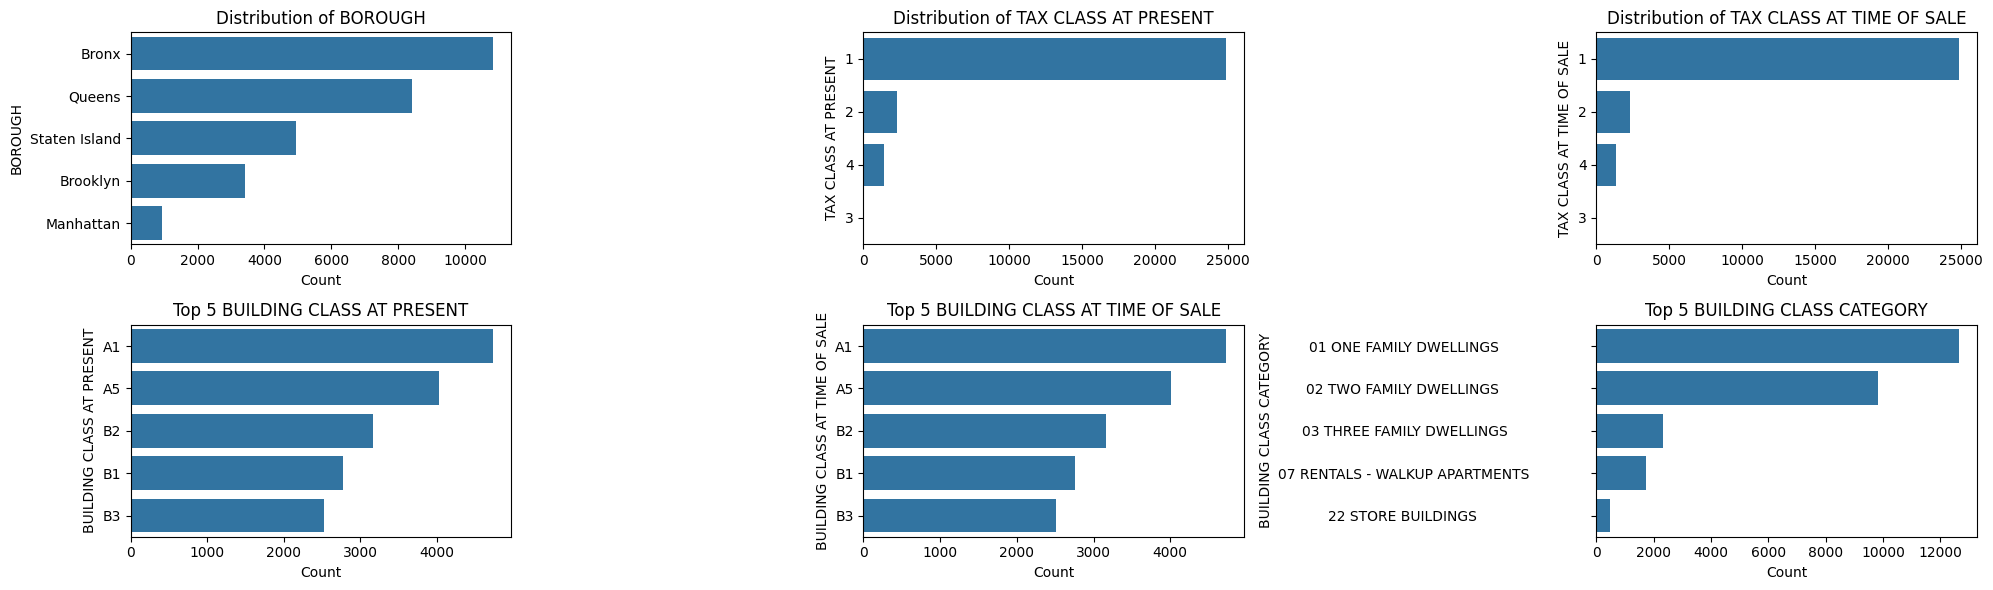

In [ ]:
cat_cols_plot = ['BOROUGH', 'TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE',
                 'BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE' ,'BUILDING CLASS CATEGORY']

fig, axes = plt.subplots(2, 3, figsize=(20, 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):

    if col in ['BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE', 'BUILDING CLASS CATEGORY']:
        top_5 = nyc_df[col].value_counts().head(5).index
        sns.countplot(data=nyc_df[nyc_df[col].isin(top_5)], y=col, ax=axes[i], order=top_5)
        axes[i].set_title(f'Top 5 {col}')
    else:
        sns.countplot(data=nyc_df, y=col, ax=axes[i], order=nyc_df[col].value_counts().index)
        axes[i].set_title(f'Distribution of {col}')

    axes[i].set_xlabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

I took the top 5 Building Class categories in the features because there were too many unique values to plot. As we can see here most of the properties in this dataset come from single family homes, which is what Tax Class = 1 represents. And most of these seem to be from the Bronx, Queens, and Staten Island. And the Building Class is fairly the same at present and time of sale as well. Let us now check how it is distributed with regard to sale price. We can also see that Building class at Time of sale and Building class at present coincide as well, which can be useful for feature learning to determine if we need both. Same for building class category too since it is a more general variation.

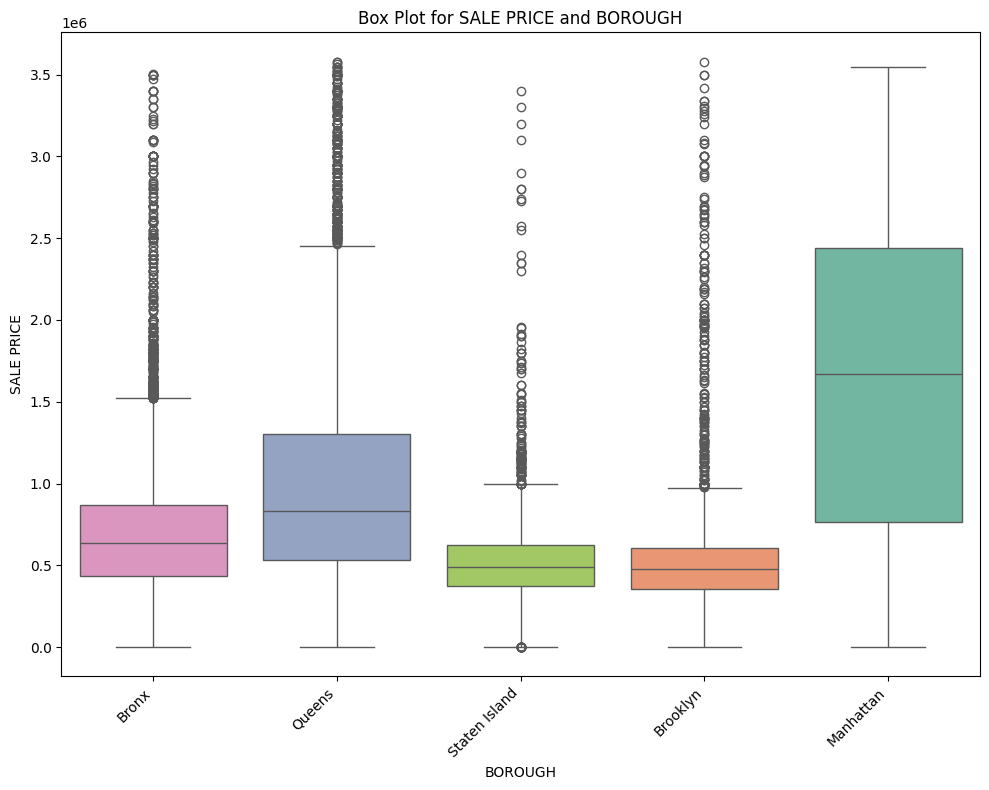

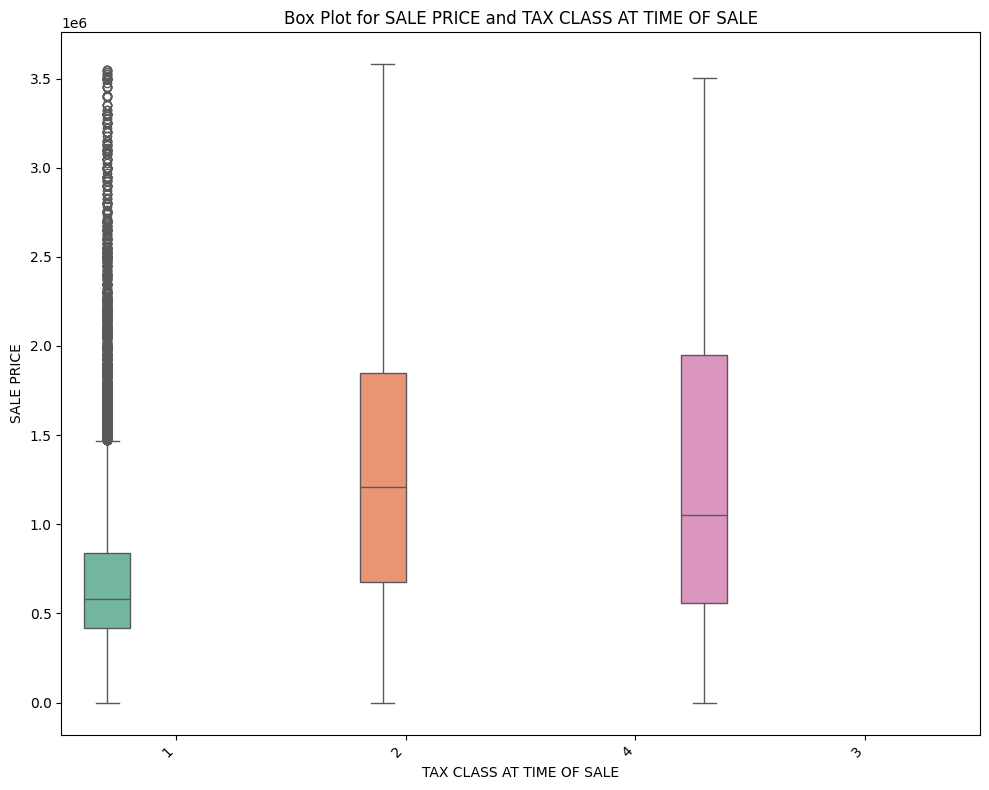

In [ ]:
cat_cols_plot = ['BOROUGH', 'TAX CLASS AT TIME OF SALE']

# Filter sale price to 85th percentile
price_85 = nyc_df['SALE PRICE'].quantile(0.95)
nyc_df_filtered = nyc_df[nyc_df['SALE PRICE'] <= price_85].copy()

for col in cat_cols_plot:
    plt.figure(figsize=(10, 8))

    order = nyc_df_filtered[col].value_counts().index.tolist()

    sns.boxplot(x=col, y='SALE PRICE', data=nyc_df_filtered,
                hue=col, order=order, palette='Set2',
                legend=False)


    plt.title(f'Box Plot for SALE PRICE and {col}')
    plt.xlabel(col)
    plt.ylabel('SALE PRICE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

We can see that more of the expensive properties lie in Manhattan, making it having the biggest range as well, which makes sense in NYC. There are tons of outliers in the other areas most likely due to there being a more sparse distribution of types of properties, with more varieties of residential areas being there as well. We can also see this with respect to tax class where higher sale prices are found more within non-residential tax classes like 2 and 4.

# 5. Feature Engineering & Final Preprocessing

Based on prior observations and insights, here we will perform all of the feature learning and extraction. Let us first review the dataset.

In [ ]:
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BLOCK                           28516 non-null  int64   
 5   LOT                             28516 non-null  int64   
 6   BUILDING CLASS AT PRESENT       28516 non-null  category
 7   ADDRESS                         28516 non-null  category
 8   ZIP CODE                        28516 non-null  int64   
 9   RESIDENTIAL UNITS               28516 non-null  int64   
 10  COMMERCIAL UNITS                28516 non-null  int64   
 11  TOTAL UNITS                     28516 non-null  int64   
 12  LAND SQUARE FEET  

We can see that ADDRESS is still contained within the dataframe, so we will drop this since its more of an identifier

In [ ]:
# Dropping ADDRESS

nyc_df.drop(['ADDRESS'], axis=1, inplace=True)
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BLOCK                           28516 non-null  int64   
 5   LOT                             28516 non-null  int64   
 6   BUILDING CLASS AT PRESENT       28516 non-null  category
 7   ZIP CODE                        28516 non-null  int64   
 8   RESIDENTIAL UNITS               28516 non-null  int64   
 9   COMMERCIAL UNITS                28516 non-null  int64   
 10  TOTAL UNITS                     28516 non-null  int64   
 11  LAND SQUARE FEET                28516 non-null  float64 
 12  GROSS SQUARE FEET 

We can also create a new feature now to describe the age of the property  instead of having sale year and year built as separate, which will provide better insight since sale year only has two values 2016, 2017 which won't be that great of a feature.

In [ ]:
# Creating new feature AGE OF PROPERTY and dropping SALE YEAR and YEAR BUILT

nyc_df['AGE OF PROPERTY'] = nyc_df['SALE YEAR'] - nyc_df['YEAR BUILT']

nyc_df.drop(['SALE YEAR', 'YEAR BUILT'], axis=1, inplace=True)
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BLOCK                           28516 non-null  int64   
 5   LOT                             28516 non-null  int64   
 6   BUILDING CLASS AT PRESENT       28516 non-null  category
 7   ZIP CODE                        28516 non-null  int64   
 8   RESIDENTIAL UNITS               28516 non-null  int64   
 9   COMMERCIAL UNITS                28516 non-null  int64   
 10  TOTAL UNITS                     28516 non-null  int64   
 11  LAND SQUARE FEET                28516 non-null  float64 
 12  GROSS SQUARE FEET 

Judging by the NYC government glossary, we can remove TOTAL UNITS since it should just be a linear combination of RESIDENTIAL UNITS and COMMERCIAL UNITs. This is further justified by the high correlation between RESIDENTIAL UNITS and TOTAL UNITS.

In [ ]:
# Dropping Total Units

nyc_df.drop(['TOTAL UNITS'], axis=1, inplace=True)
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BLOCK                           28516 non-null  int64   
 5   LOT                             28516 non-null  int64   
 6   BUILDING CLASS AT PRESENT       28516 non-null  category
 7   ZIP CODE                        28516 non-null  int64   
 8   RESIDENTIAL UNITS               28516 non-null  int64   
 9   COMMERCIAL UNITS                28516 non-null  int64   
 10  LAND SQUARE FEET                28516 non-null  float64 
 11  GROSS SQUARE FEET               28516 non-null  float64 
 12  TAX CLASS AT TIME 

Further looking at the glossary, we can see that BLOCK and LOT are subsets of Borough and are more meant for distinguishing between one condo from another in a building, so they act more like IDs. And since they also have a very large number of unique values, it would be better to just remove them as well.

In [ ]:
# Dropping BLOCK and LOT

nyc_df.drop(['BLOCK', 'LOT'], axis=1, inplace=True)
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         28516 non-null  category
 1   NEIGHBORHOOD                    28516 non-null  category
 2   BUILDING CLASS CATEGORY         28516 non-null  category
 3   TAX CLASS AT PRESENT            28516 non-null  category
 4   BUILDING CLASS AT PRESENT       28516 non-null  category
 5   ZIP CODE                        28516 non-null  int64   
 6   RESIDENTIAL UNITS               28516 non-null  int64   
 7   COMMERCIAL UNITS                28516 non-null  int64   
 8   LAND SQUARE FEET                28516 non-null  float64 
 9   GROSS SQUARE FEET               28516 non-null  float64 
 10  TAX CLASS AT TIME OF SALE       28516 non-null  category
 11  BUILDING CLASS AT TIME OF SALE  28516 non-null  category
 12  SALE PRICE        

Now let us check if TAX CLASS AT PRESENT, BUILDING CLASS AT PRESENT match with the ones at the TIME OF SALE to see if we can determine that we can remove either set of the columns.

In [ ]:
# Create dataframes for mismatches of each type of class

tax_class_mismatch = nyc_df[nyc_df['TAX CLASS AT PRESENT'] != nyc_df['TAX CLASS AT TIME OF SALE']]
print(f"TAX CLASS mismatches: {len(tax_class_mismatch)/len(nyc_df)*100}% of samples")

building_class_mismatch = nyc_df[nyc_df['BUILDING CLASS AT PRESENT'] != nyc_df['BUILDING CLASS AT TIME OF SALE']]
print(f"BUILDING CLASS mismatches: {len(building_class_mismatch)/len(nyc_df)*100}% samples")

either_mismatch = nyc_df[
    (nyc_df['TAX CLASS AT PRESENT'] != nyc_df['TAX CLASS AT TIME OF SALE']) |
    (nyc_df['BUILDING CLASS AT PRESENT'] != nyc_df['BUILDING CLASS AT TIME OF SALE'])
]
print(f"Either mismatch: {len(either_mismatch)/len(nyc_df)*100}% of samples")

both_mismatch = nyc_df[
    (nyc_df['TAX CLASS AT PRESENT'] != nyc_df['TAX CLASS AT TIME OF SALE']) &
    (nyc_df['BUILDING CLASS AT PRESENT'] != nyc_df['BUILDING CLASS AT TIME OF SALE'])
]
print(f"Both mismatch: {len(both_mismatch)/len(nyc_df)*100}% of samples")

TAX CLASS mismatches: 0.03156122878384065% of samples
BUILDING CLASS mismatches: 0.3085986814419975% samples
Either mismatch: 0.3085986814419975% of samples
Both mismatch: 0.03156122878384065% of samples


Taking a look at this, we can see for Tax Class, only 0.03% of samples have changed their tax class between the present and at the time of sale and then only 0.3% of samples changed their building class as well. Due to these very low amount of samples, it would bring greater benefit to instead develop two new columns, TAX CLASS CHANGED and BUILDING CLASS CHANGED, which indicate whether samples changed between the time frames. The reasoning behind this is it will significantly bring down dimensionality since Building class itself has over 100 unique values, and keeping both states would give 2x that. So I will create indicator columns instead to remedy this.

In [ ]:
# Create binary columns for changes
nyc_df['TAX CLASS CHANGED'] = (nyc_df['TAX CLASS AT PRESENT'] != nyc_df['TAX CLASS AT TIME OF SALE']).astype(int)
nyc_df['BUILDING CLASS CHANGED'] = (nyc_df['BUILDING CLASS AT PRESENT'] != nyc_df['BUILDING CLASS AT TIME OF SALE']).astype(int)

# Drop the time of sale columns
nyc_df.drop(['TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE'], axis=1, inplace=True)

nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   BOROUGH                    28516 non-null  category
 1   NEIGHBORHOOD               28516 non-null  category
 2   BUILDING CLASS CATEGORY    28516 non-null  category
 3   TAX CLASS AT PRESENT       28516 non-null  category
 4   BUILDING CLASS AT PRESENT  28516 non-null  category
 5   ZIP CODE                   28516 non-null  int64   
 6   RESIDENTIAL UNITS          28516 non-null  int64   
 7   COMMERCIAL UNITS           28516 non-null  int64   
 8   LAND SQUARE FEET           28516 non-null  float64 
 9   GROSS SQUARE FEET          28516 non-null  float64 
 10  SALE PRICE                 28516 non-null  float64 
 11  SALE MONTH                 28516 non-null  int32   
 12  AGE OF PROPERTY            28516 non-null  int64   
 13  TAX CLASS CHANGED          2851

On that note about Building class, 'BUILDING CLASS CATEGORY' is a field meant to identify similar properties by broad usage (e.g. One Family Homes) without looking up individual Building Classes. Since 'BUILDING CLASS AT PRESENT' is a more in depth version of this, I am decided to remove it since it may act as a redundant feature in this case.

In [ ]:
nyc_df.drop((['BUILDING CLASS CATEGORY']), axis=1, inplace=True)
nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   BOROUGH                    28516 non-null  category
 1   NEIGHBORHOOD               28516 non-null  category
 2   TAX CLASS AT PRESENT       28516 non-null  category
 3   BUILDING CLASS AT PRESENT  28516 non-null  category
 4   ZIP CODE                   28516 non-null  int64   
 5   RESIDENTIAL UNITS          28516 non-null  int64   
 6   COMMERCIAL UNITS           28516 non-null  int64   
 7   LAND SQUARE FEET           28516 non-null  float64 
 8   GROSS SQUARE FEET          28516 non-null  float64 
 9   SALE PRICE                 28516 non-null  float64 
 10  SALE MONTH                 28516 non-null  int32   
 11  AGE OF PROPERTY            28516 non-null  int64   
 12  TAX CLASS CHANGED          28516 non-null  int64   
 13  BUILDING CLASS CHANGED     2851

Now, since Neighborhood and Zip Code have a high number of unique values, I have decided to drop ZIP CODE since it is more like an identifier for postal code and won't capture the general housing price in its regions. The reason why I say this is because of the neighborhood brand effect on housing prices, which can capture things like poverty-stricken areas vs high priced areas since it is not a more general convenience feature like ZIP CODE.

In [ ]:
nyc_df.drop((['ZIP CODE']), axis=1, inplace=True)

# Converting neighborhood to object type because it needs special encoding scheme later on
nyc_df['NEIGHBORHOOD'] = nyc_df['NEIGHBORHOOD'].astype(object)

nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   BOROUGH                    28516 non-null  category
 1   NEIGHBORHOOD               28516 non-null  object  
 2   TAX CLASS AT PRESENT       28516 non-null  category
 3   BUILDING CLASS AT PRESENT  28516 non-null  category
 4   RESIDENTIAL UNITS          28516 non-null  int64   
 5   COMMERCIAL UNITS           28516 non-null  int64   
 6   LAND SQUARE FEET           28516 non-null  float64 
 7   GROSS SQUARE FEET          28516 non-null  float64 
 8   SALE PRICE                 28516 non-null  float64 
 9   SALE MONTH                 28516 non-null  int32   
 10  AGE OF PROPERTY            28516 non-null  int64   
 11  TAX CLASS CHANGED          28516 non-null  int64   
 12  BUILDING CLASS CHANGED     28516 non-null  int64   
dtypes: category(3), float64(3), int

Now as we know, the dataset has many outliers giving a large amount of skew in the house price. This largely affects the model's performance since the linear regression models we will use are sensitive to outliers due to them using least squares method. After going through common methods for dealing with outliers in regression, I have decided to leave them be however to give the true variance to the model.

In [ ]:
nyc_df.describe().apply(lambda x: x.apply('{0:.2f}'.format)).transpose()

,count,mean,std,min,25%,50%,75%,max
RESIDENTIAL UNITS,28516.00,3.03,20.12,0.00,1.00,2.00,2.00,1844.00
COMMERCIAL UNITS,28516.00,0.31,13.98,0.00,0.00,0.00,0.00,2261.00
LAND SQUARE FEET,28516.00,4136.56,36765.95,200.00,2000.00,2500.00,4000.00,4228300.00
GROSS SQUARE FEET,28516.00,4395.88,33649.46,120.00,1360.00,1870.00,2652.75,3750565.00
SALE PRICE,28516.00,1676160.92,17222287.28,19.00,431030.00,630000.00,966319.00,2210000000.00
SALE MONTH,28516.00,6.60,3.47,1.00,4.00,6.00,10.00,12.00
AGE OF PROPERTY,28516.00,76.03,30.47,0.00,57.00,86.00,97.00,217.00
TAX CLASS CHANGED,28516.00,0.00,0.02,0.00,0.00,0.00,0.00,1.00
BUILDING CLASS CHANGED,28516.00,0.00,0.06,0.00,0.00,0.00,0.00,1.00


So we can see that the bottom 25% is at around 431k dollars while the top 75% are at around 966k dollars. With a value minimum value of 19 dollars, there isn't anyway to determine whether this was a legitmate sale or not. This could most likely be a gift sale or something of that sort, but because of the complexity, I will just leave it as it is.

According to Zillow, they recommend dates to sell properties based on seasons like spring, fall etc. Which can indicate that months themselves might be too short of a span to consider. So I will transfer SALE MONTH to sale season which will reduce dimensionality from 12 to 4.

In [ ]:
# Function to convert months to season

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Create SALE SEASON column
nyc_df['SALE SEASON'] = nyc_df['SALE MONTH'].apply(month_to_season)

# Convert to category dtype
nyc_df['SALE SEASON'] = nyc_df['SALE SEASON'].astype('category')

# Drop SALE MONTH column if you don't need it anymore
nyc_df.drop(['SALE MONTH'], axis=1, inplace=True)

nyc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   BOROUGH                    28516 non-null  category
 1   NEIGHBORHOOD               28516 non-null  object  
 2   TAX CLASS AT PRESENT       28516 non-null  category
 3   BUILDING CLASS AT PRESENT  28516 non-null  category
 4   RESIDENTIAL UNITS          28516 non-null  int64   
 5   COMMERCIAL UNITS           28516 non-null  int64   
 6   LAND SQUARE FEET           28516 non-null  float64 
 7   GROSS SQUARE FEET          28516 non-null  float64 
 8   SALE PRICE                 28516 non-null  float64 
 9   AGE OF PROPERTY            28516 non-null  int64   
 10  TAX CLASS CHANGED          28516 non-null  int64   
 11  BUILDING CLASS CHANGED     28516 non-null  int64   
 12  SALE SEASON                28516 non-null  category
dtypes: category(4), float64(3), int

Now we will one hot encode these corresponding columns: BOROUGH, TAX CLASS AT PRESENT, BUILDING CLASS AT PRESENT, SALE SEASON. As these are the primary nominal category variables. We will perform a different encoding scheme for neighborhood

In [ ]:
# One Hot Encoding

columns_to_encode = ['BOROUGH', 'TAX CLASS AT PRESENT', 'BUILDING CLASS AT PRESENT', 'SALE SEASON']

for col in nyc_df.select_dtypes(include='category').columns:
    nyc_df[col] = nyc_df[col].astype(str)

nyc_df_encoded = pd.get_dummies(nyc_df, columns=columns_to_encode, dtype=int)
nyc_df_encoded.info()
nyc_df_encoded.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Columns: 144 entries, NEIGHBORHOOD to SALE SEASON_Winter
dtypes: float64(3), int64(140), object(1)
memory usage: 31.3+ MB


,NEIGHBORHOOD,RESIDENTIAL UNITS,COMMERCIAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,SALE PRICE,AGE OF PROPERTY,TAX CLASS CHANGED,BUILDING CLASS CHANGED,BOROUGH_Bronx,BOROUGH_Brooklyn,BOROUGH_Manhattan,BOROUGH_Queens,BOROUGH_Staten Island,TAX CLASS AT PRESENT_1,TAX CLASS AT PRESENT_2,TAX CLASS AT PRESENT_4,BUILDING CLASS AT PRESENT_A0,BUILDING CLASS AT PRESENT_A1,BUILDING CLASS AT PRESENT_A2,BUILDING CLASS AT PRESENT_A3,BUILDING CLASS AT PRESENT_A4,BUILDING CLASS AT PRESENT_A5,BUILDING CLASS AT PRESENT_A6,BUILDING CLASS AT PRESENT_A7,BUILDING CLASS AT PRESENT_A9,BUILDING CLASS AT PRESENT_B1,BUILDING CLASS AT PRESENT_B2,BUILDING CLASS AT PRESENT_B3,BUILDING CLASS AT PRESENT_B9,BUILDING CLASS AT PRESENT_C0,BUILDING CLASS AT PRESENT_C1,BUILDING CLASS AT PRESENT_C2,BUILDING CLASS AT PRESENT_C3,BUILDING CLASS AT PRESENT_C4,BUILDING CLASS AT PRESENT_C5,BUILDING CLASS AT PRESENT_C6,BUILDING CLASS AT PRESENT_C7,BUILDING CLASS AT PRESENT_C9,BUILDING CLASS AT PRESENT_CM,BUILDING CLASS AT PRESENT_D1,BUILDING CLASS AT PRESENT_D2,BUILDING CLASS AT PRESENT_D3,BUILDING CLASS AT PRESENT_D4,BUILDING CLASS AT PRESENT_D5,BUILDING CLASS AT PRESENT_D6,BUILDING CLASS AT PRESENT_D7,BUILDING CLASS AT PRESENT_D9,BUILDING CLASS AT PRESENT_E1,BUILDING CLASS AT PRESENT_E2,BUILDING CLASS AT PRESENT_E7,BUILDING CLASS AT PRESENT_E9,BUILDING CLASS AT PRESENT_F1,BUILDING CLASS AT PRESENT_F2,BUILDING CLASS AT PRESENT_F4,BUILDING CLASS AT PRESENT_F5,BUILDING CLASS AT PRESENT_F9,BUILDING CLASS AT PRESENT_G0,BUILDING CLASS AT PRESENT_G1,BUILDING CLASS AT PRESENT_G2,BUILDING CLASS AT PRESENT_G4,BUILDING CLASS AT PRESENT_G5,BUILDING CLASS AT PRESENT_G8,BUILDING CLASS AT PRESENT_G9,BUILDING CLASS AT PRESENT_GU,BUILDING CLASS AT PRESENT_GW,BUILDING CLASS AT PRESENT_H1,BUILDING CLASS AT PRESENT_H2,BUILDING CLASS AT PRESENT_H3,BUILDING CLASS AT PRESENT_H4,BUILDING CLASS AT PRESENT_H6,BUILDING CLASS AT PRESENT_H8,BUILDING CLASS AT PRESENT_H9,BUILDING CLASS AT PRESENT_HB,BUILDING CLASS AT PRESENT_HH,BUILDING CLASS AT PRESENT_HR,BUILDING CLASS AT PRESENT_HS,BUILDING CLASS AT PRESENT_I1,BUILDING CLASS AT PRESENT_I3,BUILDING CLASS AT PRESENT_I4,BUILDING CLASS AT PRESENT_I5,BUILDING CLASS AT PRESENT_I6,BUILDING CLASS AT PRESENT_I7,BUILDING CLASS AT PRESENT_I9,BUILDING CLASS AT PRESENT_J1,BUILDING CLASS AT PRESENT_J4,BUILDING CLASS AT PRESENT_J8,BUILDING CLASS AT PRESENT_K1,BUILDING CLASS AT PRESENT_K2,BUILDING CLASS AT PRESENT_K3,BUILDING CLASS AT PRESENT_K4,BUILDING CLASS AT PRESENT_K5,BUILDING CLASS AT PRESENT_K6,BUILDING CLASS AT PRESENT_K7,BUILDING CLASS AT PRESENT_K8,BUILDING CLASS AT PRESENT_K9,BUILDING CLASS AT PRESENT_L1,BUILDING CLASS AT PRESENT_L3,BUILDING CLASS AT PRESENT_L8,BUILDING CLASS AT PRESENT_L9,BUILDING CLASS AT PRESENT_M1,BUILDING CLASS AT PRESENT_M2,BUILDING CLASS AT PRESENT_M3,BUILDING CLASS AT PRESENT_M4,BUILDING CLASS AT PRESENT_M9,BUILDING CLASS AT PRESENT_N2,BUILDING CLASS AT PRESENT_N9,BUILDING CLASS AT PRESENT_O1,BUILDING CLASS AT PRESENT_O2,BUILDING CLASS AT PRESENT_O3,BUILDING CLASS AT PRESENT_O4,BUILDING CLASS AT PRESENT_O5,BUILDING CLASS AT PRESENT_O6,BUILDING CLASS AT PRESENT_O7,BUILDING CLASS AT PRESENT_O8,BUILDING CLASS AT PRESENT_O9,BUILDING CLASS AT PRESENT_P2,BUILDING CLASS AT PRESENT_P5,BUILDING CLASS AT PRESENT_P6,BUILDING CLASS AT PRESENT_P8,BUILDING CLASS AT PRESENT_P9,BUILDING CLASS AT PRESENT_Q8,BUILDING CLASS AT PRESENT_R0,BUILDING CLASS AT PRESENT_RR,BUILDING CLASS AT PRESENT_S0,BUILDING CLASS AT PRESENT_S1,BUILDING CLASS AT PRESENT_S2,BUILDING CLASS AT PRESENT_S3,BUILDING CLASS AT PRESENT_S4,BUILDING CLASS AT PRESENT_S5,BUILDING CLASS AT PRESENT_S9,BUILDING CLASS AT PRESENT_W1,BUILDING CLASS AT PRESENT_W2,BUILDING CLASS AT PRESENT_W3,BUILDING CLASS AT PRESENT_W4,BUILDING CLASS AT PRESENT_W8,BUILDING CLASS AT PRESENT_W9,BUILDING CLASS AT PRESENT_Y3,BUILDING CLASS AT PRESENT_Z0,BUILDING CLASS AT PRESENT_Z9,SALE SEASON_Fall,SALE SEASON_Spring,SALE SEASON_Summer,SALE SEASON_Winter
0,ALPHABET CITY,5,0,1633.0,6440.0,6.625e+06,117,0,0,

We will log scale GSF, LSF, and the Units due to the massive scale of numbers for SALE PRICE, this would benefit the model since it is based on the least squares method and does not affect the variance and mean like other standardization methods. As it also keeps the same relationship between the variables. We also see massive skew for these features as well.

In [ ]:
# Lets verify skew

nyc_df_encoded.skew(numeric_only=True)

,0
RESIDENTIAL UNITS,46.034
COMMERCIAL UNITS,150.196
LAND SQUARE FEET,83.430
GROSS SQUARE FEET,61.837
SALE PRICE,87.755
AGE OF PROPERTY,-0.797
TAX CLASS CHANGED,56.265
BUILDING CLASS CHANGED,17.919
BOROUGH_Bronx,0.497
BOROUGH_Brooklyn,2.335


In [ ]:
# Create dataframe for model specifcally
nyc_df_ols = nyc_df_encoded.copy()

# Perform log+1 transformation to account for 0 values
nyc_df_ols['SALE PRICE'] = np.log1p(nyc_df_encoded['SALE PRICE'])
nyc_df_ols['LAND SQUARE FEET'] = np.log1p(nyc_df_encoded['LAND SQUARE FEET'])
nyc_df_ols['GROSS SQUARE FEET'] = np.log1p(nyc_df_encoded['GROSS SQUARE FEET'])
nyc_df_ols['RESIDENTIAL UNITS'] = np.log1p(nyc_df_encoded['RESIDENTIAL UNITS'])
nyc_df_ols['COMMERCIAL UNITS'] = np.log1p(nyc_df_encoded['COMMERCIAL UNITS'])

nyc_df_ols.head()

,NEIGHBORHOOD,RESIDENTIAL UNITS,COMMERCIAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,SALE PRICE,AGE OF PROPERTY,TAX CLASS CHANGED,BUILDING CLASS CHANGED,BOROUGH_Bronx,BOROUGH_Brooklyn,BOROUGH_Manhattan,BOROUGH_Queens,BOROUGH_Staten Island,TAX CLASS AT PRESENT_1,TAX CLASS AT PRESENT_2,TAX CLASS AT PRESENT_4,BUILDING CLASS AT PRESENT_A0,BUILDING CLASS AT PRESENT_A1,BUILDING CLASS AT PRESENT_A2,BUILDING CLASS AT PRESENT_A3,BUILDING CLASS AT PRESENT_A4,BUILDING CLASS AT PRESENT_A5,BUILDING CLASS AT PRESENT_A6,BUILDING CLASS AT PRESENT_A7,BUILDING CLASS AT PRESENT_A9,BUILDING CLASS AT PRESENT_B1,BUILDING CLASS AT PRESENT_B2,BUILDING CLASS AT PRESENT_B3,BUILDING CLASS AT PRESENT_B9,BUILDING CLASS AT PRESENT_C0,BUILDING CLASS AT PRESENT_C1,BUILDING CLASS AT PRESENT_C2,BUILDING CLASS AT PRESENT_C3,BUILDING CLASS AT PRESENT_C4,BUILDING CLASS AT PRESENT_C5,BUILDING CLASS AT PRESENT_C6,BUILDING CLASS AT PRESENT_C7,BUILDING CLASS AT PRESENT_C9,BUILDING CLASS AT PRESENT_CM,BUILDING CLASS AT PRESENT_D1,BUILDING CLASS AT PRESENT_D2,BUILDING CLASS AT PRESENT_D3,BUILDING CLASS AT PRESENT_D4,BUILDING CLASS AT PRESENT_D5,BUILDING CLASS AT PRESENT_D6,BUILDING CLASS AT PRESENT_D7,BUILDING CLASS AT PRESENT_D9,BUILDING CLASS AT PRESENT_E1,BUILDING CLASS AT PRESENT_E2,BUILDING CLASS AT PRESENT_E7,BUILDING CLASS AT PRESENT_E9,BUILDING CLASS AT PRESENT_F1,BUILDING CLASS AT PRESENT_F2,BUILDING CLASS AT PRESENT_F4,BUILDING CLASS AT PRESENT_F5,BUILDING CLASS AT PRESENT_F9,BUILDING CLASS AT PRESENT_G0,BUILDING CLASS AT PRESENT_G1,BUILDING CLASS AT PRESENT_G2,BUILDING CLASS AT PRESENT_G4,BUILDING CLASS AT PRESENT_G5,BUILDING CLASS AT PRESENT_G8,BUILDING CLASS AT PRESENT_G9,BUILDING CLASS AT PRESENT_GU,BUILDING CLASS AT PRESENT_GW,BUILDING CLASS AT PRESENT_H1,BUILDING CLASS AT PRESENT_H2,BUILDING CLASS AT PRESENT_H3,BUILDING CLASS AT PRESENT_H4,BUILDING CLASS AT PRESENT_H6,BUILDING CLASS AT PRESENT_H8,BUILDING CLASS AT PRESENT_H9,BUILDING CLASS AT PRESENT_HB,BUILDING CLASS AT PRESENT_HH,BUILDING CLASS AT PRESENT_HR,BUILDING CLASS AT PRESENT_HS,BUILDING CLASS AT PRESENT_I1,BUILDING CLASS AT PRESENT_I3,BUILDING CLASS AT PRESENT_I4,BUILDING CLASS AT PRESENT_I5,BUILDING CLASS AT PRESENT_I6,BUILDING CLASS AT PRESENT_I7,BUILDING CLASS AT PRESENT_I9,BUILDING CLASS AT PRESENT_J1,BUILDING CLASS AT PRESENT_J4,BUILDING CLASS AT PRESENT_J8,BUILDING CLASS AT PRESENT_K1,BUILDING CLASS AT PRESENT_K2,BUILDING CLASS AT PRESENT_K3,BUILDING CLASS AT PRESENT_K4,BUILDING CLASS AT PRESENT_K5,BUILDING CLASS AT PRESENT_K6,BUILDING CLASS AT PRESENT_K7,BUILDING CLASS AT PRESENT_K8,BUILDING CLASS AT PRESENT_K9,BUILDING CLASS AT PRESENT_L1,BUILDING CLASS AT PRESENT_L3,BUILDING CLASS AT PRESENT_L8,BUILDING CLASS AT PRESENT_L9,BUILDING CLASS AT PRESENT_M1,BUILDING CLASS AT PRESENT_M2,BUILDING CLASS AT PRESENT_M3,BUILDING CLASS AT PRESENT_M4,BUILDING CLASS AT PRESENT_M9,BUILDING CLASS AT PRESENT_N2,BUILDING CLASS AT PRESENT_N9,BUILDING CLASS AT PRESENT_O1,BUILDING CLASS AT PRESENT_O2,BUILDING CLASS AT PRESENT_O3,BUILDING CLASS AT PRESENT_O4,BUILDING CLASS AT PRESENT_O5,BUILDING CLASS AT PRESENT_O6,BUILDING CLASS AT PRESENT_O7,BUILDING CLASS AT PRESENT_O8,BUILDING CLASS AT PRESENT_O9,BUILDING CLASS AT PRESENT_P2,BUILDING CLASS AT PRESENT_P5,BUILDING CLASS AT PRESENT_P6,BUILDING CLASS AT PRESENT_P8,BUILDING CLASS AT PRESENT_P9,BUILDING CLASS AT PRESENT_Q8,BUILDING CLASS AT PRESENT_R0,BUILDING CLASS AT PRESENT_RR,BUILDING CLASS AT PRESENT_S0,BUILDING CLASS AT PRESENT_S1,BUILDING CLASS AT PRESENT_S2,BUILDING CLASS AT PRESENT_S3,BUILDING CLASS AT PRESENT_S4,BUILDING CLASS AT PRESENT_S5,BUILDING CLASS AT PRESENT_S9,BUILDING CLASS AT PRESENT_W1,BUILDING CLASS AT PRESENT_W2,BUILDING CLASS AT PRESENT_W3,BUILDING CLASS AT PRESENT_W4,BUILDING CLASS AT PRESENT_W8,BUILDING CLASS AT PRESENT_W9,BUILDING CLASS AT PRESENT_Y3,BUILDING CLASS AT PRESENT_Z0,BUILDING CLASS AT PRESENT_Z9,SALE SEASON_Fall,SALE SEASON_Spring,SALE SEASON_Summer,SALE SEASON_Winter
0,ALPHABET CITY,1.792,0.0,7.399,8.770,15.706,117,0,0

# 6. Regression Methods & Comparative Analysis

Here we will compare the different Least Squares Regression Methods which will involve Ridge and Lasso.

I used target encoding for the Neighborhoods feature, which replaces the category with the mean sale price for that category. This is a feature that is used categorical variables such as neighborhood with large dimensionality. It comes with limitations such as overfitting if done wrong, but this is resolved by performing this in each fold instead of before cross-validation.

In [ ]:
# Contains target encoder needed for NEIGHBORHOODS feature

!pip install category-encoders

In [ ]:
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Separate features and target
X = nyc_df_ols.drop('SALE PRICE', axis=1)
y = nyc_df_ols['SALE PRICE']

# Define columns
continuous_cols = ['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'LAND SQUARE FEET',
                   'GROSS SQUARE FEET', 'AGE OF PROPERTY']
target_encode_cols = ['NEIGHBORHOOD']
ohe_cols = [col for col in X.columns if col not in continuous_cols and col not in target_encode_cols]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), continuous_cols),
        ('target_encoder', TargetEncoder(target_type='continuous', smooth='auto', cv=5),
         target_encode_cols),
        ('passthrough', 'passthrough', ohe_cols)
    ],
    remainder='drop'
)

# Define alpha values to test
alphas = np.logspace(-3, 3, 50)  # 50 values from 0.001 to 1000

# Initialize cross-validation

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=4, shuffle=True, random_state=42)


### RIDGE REGRESSION ###

print("=" * 70)
print("RIDGE REGRESSION WITH NESTED CV")
print("=" * 70)

ridge_nested_results = []

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\nOuter Fold {fold_id + 1}/5")

    # Split data for this outer fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Create fresh pipeline for this fold
    ridge_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(max_iter=10000))
    ])

    # GridSearchCV for hyperparameter tuning
    ridge_grid = GridSearchCV(
        estimator=ridge_pipeline,
        param_grid={'regressor__alpha': alphas},
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        return_train_score=False
    )

    # Fit grid search on training data
    ridge_grid.fit(X_train, y_train)

    # Get best model and predict on held-out test fold
    best_model = ridge_grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Also get training predictions to monitor overfitting
    y_train_pred = best_model.predict(X_train)

    # Calculate metrics
    test_r2 = r2_score(y_test, y_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred)

    ridge_nested_results.append({
        'outer_fold': fold_id,
        'best_alpha': ridge_grid.best_params_['regressor__alpha'],
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    })

    print(f"  Best alpha: {ridge_grid.best_params_['regressor__alpha']:.4f}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: ${test_rmse:,.2f}")

ridge_results_df = pd.DataFrame(ridge_nested_results)

print("\n" + "=" * 70)
print("RIDGE REGRESSION SUMMARY")
print("=" * 70)
print(f"Mean Test R²: {ridge_results_df['test_r2'].mean():.4f} (+/- {ridge_results_df['test_r2'].std():.4f})")
print(f"Mean Train R²: {ridge_results_df['train_r2'].mean():.4f} (+/- {ridge_results_df['train_r2'].std():.4f})")
print(f"Mean Test RMSE: ${ridge_results_df['test_rmse'].mean():,.2f} (+/- ${ridge_results_df['test_rmse'].std():,.2f})")
print(f"Mean Test MAE: ${ridge_results_df['test_mae'].mean():,.2f}")
print(f"Most Common Best Alpha: {ridge_results_df['best_alpha'].mode()[0]:.4f}")


### LASSO REGRESSION ###

print("\n" + "=" * 70)
print("LASSO REGRESSION WITH NESTED CV")
print("=" * 70)

lasso_nested_results = []

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\nOuter Fold {fold_id + 1}/5")

    # Split data for outer fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Create pipeline for this fold
    lasso_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(max_iter=5000))
    ])

    # GridSearchCV for hyperparameter tuning
    lasso_grid = GridSearchCV(
        estimator=lasso_pipeline,
        param_grid={'regressor__alpha': alphas},
        cv=inner_cv,
        scoring='r2',
        n_jobs=-1,
        return_train_score=False
    )

    # Fit grid search on training data
    lasso_grid.fit(X_train, y_train)

    # Get best model and predict on held-out test fold
    best_model = lasso_grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    # Calculate metrics
    test_r2 = r2_score(y_test, y_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_pred)

    lasso_nested_results.append({
        'outer_fold': fold_id,
        'best_alpha': lasso_grid.best_params_['regressor__alpha'],
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae
    })

    print(f"  Best alpha: {lasso_grid.best_params_['regressor__alpha']:.4f}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test RMSE: ${test_rmse:,.2f}")

lasso_results_df = pd.DataFrame(lasso_nested_results)

print("\n" + "=" * 70)
print("LASSO REGRESSION SUMMARY")
print("=" * 70)
print(f"Mean Test R²: {lasso_results_df['test_r2'].mean():.4f} (+/- {lasso_results_df['test_r2'].std():.4f})")
print(f"Mean Train R²: {lasso_results_df['train_r2'].mean():.4f} (+/- {lasso_results_df['train_r2'].std():.4f})")
print(f"Mean Test RMSE: ${lasso_results_df['test_rmse'].mean():,.2f} (+/- ${lasso_results_df['test_rmse'].std():,.2f})")
print(f"Mean Test MAE: ${lasso_results_df['test_mae'].mean():,.2f}")
print(f"Most Common Best Alpha: {lasso_results_df['best_alpha'].mode()[0]:.4f}")


### FIT ON FULL DATA FOR VISUALIZATION PURPOSES ONLY ###

ridge_pipeline_full = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(max_iter=10000))
])

lasso_pipeline_full = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=5000))
])

ridge_grid_full = GridSearchCV(
    ridge_pipeline_full,
    {'regressor__alpha': alphas},
    cv=inner_cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

lasso_grid_full = GridSearchCV(
    lasso_pipeline_full,
    {'regressor__alpha': alphas},
    cv=inner_cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

ridge_grid_full.fit(X, y)
lasso_grid_full.fit(X, y)

ridge_viz_results = pd.DataFrame(ridge_grid_full.cv_results_)
lasso_viz_results = pd.DataFrame(lasso_grid_full.cv_results_)

RIDGE REGRESSION WITH NESTED CV

Outer Fold 1/5
  Best alpha: 2.0236
  Train R²: 0.4572
  Test R²: 0.4864
  Test RMSE: $0.73

Outer Fold 2/5
  Best alpha: 2.6827
  Train R²: 0.4747
  Test R²: 0.4075
  Test RMSE: $0.89

Outer Fold 3/5
  Best alpha: 2.0236
  Train R²: 0.4630
  Test R²: 0.4573
  Test RMSE: $0.84

Outer Fold 4/5
  Best alpha: 2.6827
  Train R²: 0.4672
  Test R²: 0.4433
  Test RMSE: $0.87

Outer Fold 5/5
  Best alpha: 1.5264
  Train R²: 0.4652
  Test R²: 0.4472
  Test RMSE: $0.85

RIDGE REGRESSION SUMMARY
Mean Test R²: 0.4484 (+/- 0.0284)
Mean Train R²: 0.4655 (+/- 0.0064)
Mean Test RMSE: $0.84 (+/- $0.06)
Mean Test MAE: $0.41
Most Common Best Alpha: 2.0236

LASSO REGRESSION WITH NESTED CV

Outer Fold 1/5
  Best alpha: 0.0010
  Train R²: 0.4467
  Test R²: 0.4779
  Test RMSE: $0.74

Outer Fold 2/5
  Best alpha: 0.0010
  Train R²: 0.4650
  Test R²: 0.4035
  Test RMSE: $0.89

Outer Fold 3/5
  Best alpha: 0.0010
  Train R²: 0.4521
  Test R²: 0.4563
  Test RMSE: $0.84

Outer Fol

/tmp/ipython-input-3044008190.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax6.boxplot([ridge_gap, lasso_gap], labels=['Ridge', 'Lasso'],



NESTED CV MODEL COMPARISON
Model  Mean Test R²  Std Test R²  Mean Train R²  Overfit Gap  Mean RMSE  Mean MAE  Best Alpha
Ridge         0.448        0.028          0.465        0.017      0.836     0.410       2.024
Lasso         0.443        0.027          0.455        0.012      0.840     0.411       0.001


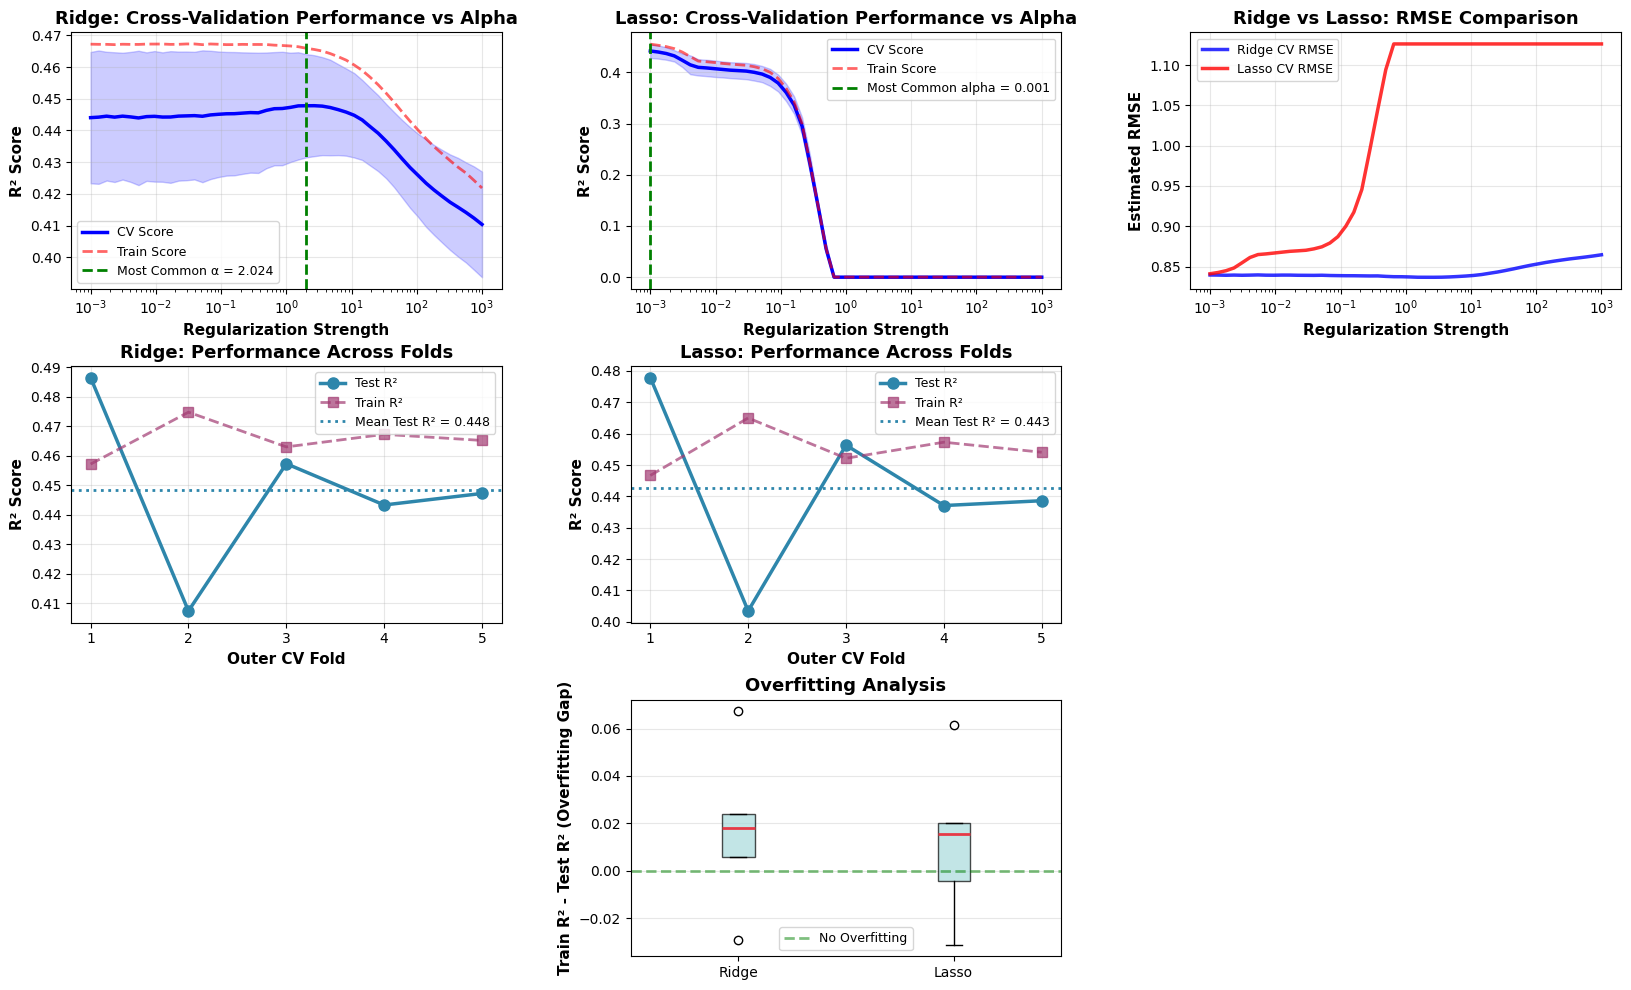

In [ ]:
### VISUALIZATION: ###

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Finding Best Alpha for Ridge
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogx(alphas, ridge_viz_results['mean_test_score'], 'b-', linewidth=2.5, label='CV Score')
ax1.fill_between(alphas,
                  ridge_viz_results['mean_test_score'] - ridge_viz_results['std_test_score'],
                  ridge_viz_results['mean_test_score'] + ridge_viz_results['std_test_score'],
                  alpha=0.2, color='b')
ax1.semilogx(alphas, ridge_viz_results['mean_train_score'], 'r--', linewidth=2, label='Train Score', alpha=0.6)
ax1.axvline(ridge_results_df['best_alpha'].mode()[0], color='g', linestyle='--', linewidth=2,
            label=f'Most Common α = {ridge_results_df["best_alpha"].mode()[0]:.3f}')
ax1.set_xlabel('Regularization Strength', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Ridge: Cross-Validation Performance vs Alpha', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)


# Finding Best Alpha for Lasso
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogx(alphas, lasso_viz_results['mean_test_score'], 'b-', linewidth=2.5, label='CV Score')
ax2.fill_between(alphas,
                  lasso_viz_results['mean_test_score'] - lasso_viz_results['std_test_score'],
                  lasso_viz_results['mean_test_score'] + lasso_viz_results['std_test_score'],
                  alpha=0.2, color='b')
ax2.semilogx(alphas, lasso_viz_results['mean_train_score'], 'r--', linewidth=2, label='Train Score', alpha=0.6)
ax2.axvline(lasso_results_df['best_alpha'].mode()[0], color='g', linestyle='--', linewidth=2,
            label=f'Most Common alpha = {lasso_results_df["best_alpha"].mode()[0]:.3f}')
ax2.set_xlabel('Regularization Strength', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('Lasso: Cross-Validation Performance vs Alpha', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# RMSE curves for Ridge vs Lasso
ax3 = fig.add_subplot(gs[0, 2])
ridge_rmse_cv = np.sqrt(-ridge_viz_results['mean_test_score'] * y.var() + y.var())
lasso_rmse_cv = np.sqrt(-lasso_viz_results['mean_test_score'] * y.var() + y.var())
ax3.semilogx(alphas, ridge_rmse_cv, 'b-', linewidth=2.5, label='Ridge CV RMSE', alpha=0.8)
ax3.semilogx(alphas, lasso_rmse_cv, 'r-', linewidth=2.5, label='Lasso CV RMSE', alpha=0.8)
ax3.set_xlabel('Regularization Strength', fontsize=11, fontweight='bold')
ax3.set_ylabel('Estimated RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Ridge vs Lasso: RMSE Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Ridge Performance Across Folds
ax4 = fig.add_subplot(gs[1, 0])
folds = ridge_results_df['outer_fold'] + 1
ax4.plot(folds, ridge_results_df['test_r2'], 'o-', linewidth=2.5, markersize=8,
         color='#2E86AB', label='Test R²')
ax4.plot(folds, ridge_results_df['train_r2'], 's--', linewidth=2, markersize=7,
         color='#A23B72', alpha=0.7, label='Train R²')
ax4.axhline(ridge_results_df['test_r2'].mean(), color='#2E86AB', linestyle=':',
            linewidth=2, label=f'Mean Test R² = {ridge_results_df["test_r2"].mean():.3f}')
ax4.set_xlabel('Outer CV Fold', fontsize=11, fontweight='bold')
ax4.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax4.set_title('Ridge: Performance Across Folds', fontsize=13, fontweight='bold')
ax4.set_xticks(folds)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Lasso Performance Across Folds
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(folds, lasso_results_df['test_r2'], 'o-', linewidth=2.5, markersize=8,
         color='#2E86AB', label='Test R²')
ax5.plot(folds, lasso_results_df['train_r2'], 's--', linewidth=2, markersize=7,
         color='#A23B72', alpha=0.7, label='Train R²')
ax5.axhline(lasso_results_df['test_r2'].mean(), color='#2E86AB', linestyle=':',
            linewidth=2, label=f'Mean Test R² = {lasso_results_df["test_r2"].mean():.3f}')
ax5.set_xlabel('Outer CV Fold', fontsize=11, fontweight='bold')
ax5.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax5.set_title('Lasso: Performance Across Folds', fontsize=13, fontweight='bold')
ax5.set_xticks(folds)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Overfitting Analysis
ax6 = fig.add_subplot(gs[2, 1])
ridge_gap = ridge_results_df['train_r2'] - ridge_results_df['test_r2']
lasso_gap = lasso_results_df['train_r2'] - lasso_results_df['test_r2']
ax6.boxplot([ridge_gap, lasso_gap], labels=['Ridge', 'Lasso'],
            patch_artist=True,
            boxprops=dict(facecolor='#A8DADC', alpha=0.7),
            medianprops=dict(color='#E63946', linewidth=2))
ax6.axhline(0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='No Overfitting')
ax6.set_ylabel('Train R² - Test R² (Overfitting Gap)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Analysis', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')


### FINAL COMPARISON TABLE ###
print("\n" + "=" * 70)
print("NESTED CV MODEL COMPARISON")
print("=" * 70)
comparison_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'Mean Test R²': [ridge_results_df['test_r2'].mean(), lasso_results_df['test_r2'].mean()],
    'Std Test R²': [ridge_results_df['test_r2'].std(), lasso_results_df['test_r2'].std()],
    'Mean Train R²': [ridge_results_df['train_r2'].mean(), lasso_results_df['train_r2'].mean()],
    'Overfit Gap': [ridge_gap.mean(), lasso_gap.mean()],
    'Mean RMSE': [ridge_results_df['test_rmse'].mean(), lasso_results_df['test_rmse'].mean()],
    'Mean MAE': [ridge_results_df['test_mae'].mean(), lasso_results_df['test_mae'].mean()],
    'Best Alpha': [ridge_results_df['best_alpha'].mode()[0], lasso_results_df['best_alpha'].mode()[0]]
})
print(comparison_df.to_string(index=False))
print("=" * 70)

These are the results between using LASSO and Ridge Regression. As we can see here after evaluation of both models, we are having an average R² score of 0.443 for Lasso and R² score of 0.448 for Ridge. We take the paramter RMSE instead of MSE here so that we can compare it more accurately to the sale price. The average RMSE of 0.84 for Lasso and average RMSE of 0.836 Ridge are what we can see for them. We see that Ridge performs better than Lasso for this task for both metrics. The parameter maximum iterations were chosen such that the models would properly converge as required by the sklearn documentation for them. As we take a look at the different plots, we can see over time the models have close train and test R^2, showing that they are not overfitting, which is further described by the overfitting plots. And for varying values of the hyperparameter we can see that Lasso has worse RMSE as well. Thus we should choose Ridge regression for this task for comparative analysis.